# 🦆 SQL with DuckDB — Ask Precise Questions of Your Data

> **What you'll learn:** how relational tables work, how to filter, aggregate and join them, why NULLs behave strangely, how window functions solve "top-N per group" and "running total" problems, how to query pandas DataFrames and Parquet files directly, and how to build leakage-free ML features in SQL — all on a real movie-ratings database, with no server to install.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Interview-level |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Pandas](02_Pandas.ipynb) (DataFrames, `groupby`, `merge`) |
| **Tested with** | Python 3.12 · duckdb 1.5 · pandas 3.0 · scikit-learn 1.9 (mini project only) |
| **Interview relevance** | ⭐⭐⭐ High — SQL rounds (joins, NULLs, window functions, top-N per group, retention and funnels) and feature pipelines for ML |

## 🤔 What Is SQL (and What Is DuckDB)?

**SQL** (Structured Query Language) is the language for asking questions of data stored in **tables**.

Think of ordering food in a restaurant. You say *what* you want ("a vegetarian pizza, no olives"), not *how* to cook it. The kitchen decides the steps. SQL works the same way: it is **declarative**. You describe the result, and the database's **query optimizer** (the "head chef") picks the fastest plan.

```
You write:  SELECT title FROM movies WHERE genres LIKE '%Comedy%'
Database:   plans → scans the column → filters → returns the rows
```

**DuckDB** is a database that runs *inside your Python process*, like a library. There is no server to install, no password, no network. It is built for **analytics** (big scans, group-bys, joins over millions of rows). People call it "SQLite for analytics".

| Term | Plain-English meaning |
|---|---|
| **Table** (relation) | A spreadsheet with fixed, typed columns |
| **Row** | One record, e.g. one rating |
| **Column** | One attribute, e.g. `rating` |
| **Schema** | The list of columns and their types |
| **Query** | A question written in SQL; its answer is itself a table |

## 🎯 Why It Matters

- **Data lives in SQL databases and warehouses.** Snowflake, BigQuery, Databricks SQL, Postgres, Redshift — most company data you will train on is reached through SQL.
- **Feature pipelines are SQL-heavy.** "Number of purchases in the last 30 days", "user's average rating before this event" — these are window functions and joins, often scheduled daily.
- **ML and LLM work needs it too:** analysing experiment logs, evaluation results, prompt/response logs, and building retrieval datasets.
- **Interviews:** ML engineer, data scientist and AI engineer loops very often include a **live SQL round** (DataLemur, LeetCode SQL 50 and StrataScratch style). Favourite topics: joins and their duplicates, NULL traps, `ROW_NUMBER` vs `RANK`, top-N per group, second-highest value, dedupe keeping the latest row, retention and funnel queries, and "why does my model look great offline but fail online?" (leaky features).

## ✅ By the End You Can

- [ ] Explain tables, keys and the *grain* of a table, and load real CSV data into DuckDB
- [ ] Write `SELECT` / `WHERE` / `GROUP BY` / `HAVING` / `ORDER BY` queries and explain their execution order
- [ ] Choose the right join (inner, left, full, semi, anti) and predict duplicate-key explosions
- [ ] Handle NULLs correctly (three-valued logic, `COUNT(*)` vs `COUNT(col)`, `NOT IN`)
- [ ] Solve top-N per group, running totals, moving averages, retention, funnels and gaps-and-islands with window functions
- [ ] Build point-in-time (leakage-free) ML features in SQL, and implement a hash join and GROUP BY from scratch

## 📋 Table of Contents

1. [Tables, Keys, and Loading Real Data](#1.-Tables,-Keys,-and-Loading-Real-Data-🟢)
2. [SELECT, WHERE, ORDER BY, LIMIT](#2.-SELECT,-WHERE,-ORDER-BY,-LIMIT-🟢)
3. [Expressions and CASE](#3.-Expressions-and-CASE-🟢)
4. [Aggregates: GROUP BY and HAVING](#4.-Aggregates:-GROUP-BY-and-HAVING-🟢)
5. [JOIN Types](#5.-JOIN-Types-🟡)
6. [Semi Joins, Anti Joins, and the Duplicate-Key Explosion](#6.-Semi-Joins,-Anti-Joins,-and-the-Duplicate-Key-Explosion-🟡)
7. [NULL Semantics](#7.-NULL-Semantics-🟡)
8. [Subqueries vs CTEs](#8.-Subqueries-vs-CTEs-🟡)
9. [Window Functions: Ranking, Top-N, Percent of Total](#9.-Window-Functions:-Ranking,-Top-N,-Percent-of-Total-🟡)
10. [Window Functions: LAG/LEAD, Running Totals, Moving Averages](#10.-Window-Functions:-LAG/LEAD,-Running-Totals,-Moving-Averages-🔴)
11. [Dates and Time Bucketing](#11.-Dates-and-Time-Bucketing-🟡)
12. [Querying pandas and Parquet Directly](#12.-Querying-pandas-and-Parquet-Directly-🟢)
13. [EXPLAIN, Indexes, and Partitioning](#13.-EXPLAIN,-Indexes,-and-Partitioning-🟡)
14. [SQL ↔ pandas Translation](#14.-SQL-↔-pandas-Translation-🟡)
15. [Classic Interview Problems](#15.-Classic-Interview-Problems-🔴)
16. [Feature Engineering in SQL for ML](#16.-Feature-Engineering-in-SQL-for-ML-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Leakage-Free-Features-to-Predict-Movie-Likes) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- `con` is an **in-memory DuckDB database** living inside this Python process.
- `sql(query)` runs a query and returns a pandas DataFrame (pretty tables in Jupyter).
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). It accepts a DuckDB result, a DataFrame, a list of rows, or a single value.

In [1]:
# %pip install -q "duckdb>=1.5" "pandas>=3.0" "pyarrow>=20" "scikit-learn>=1.5" matplotlib

import hashlib
import io
import math
import re
import sys
import time
import urllib.request
import zipfile
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"Python {sys.version.split()[0]} | DuckDB {duckdb.__version__} | pandas {pd.__version__}")

OUTPUT_DIR = Path("_outputs")                  # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = duckdb.connect()                         # in-memory database; nothing to install or start


def sql(query):
    """Run SQL on our connection and return a pandas DataFrame."""
    return con.sql(query).df()


def _as_rows(value):
    """Normalize a DuckDB relation, DataFrame, list, or scalar into a list of tuples."""
    if isinstance(value, duckdb.DuckDBPyRelation):
        return value.fetchall()
    if isinstance(value, pd.DataFrame):
        return list(value.itertuples(index=False, name=None))
    if isinstance(value, (list, tuple)) and value and isinstance(value[0], (list, tuple)):
        return [tuple(row) for row in value]
    if isinstance(value, (list, tuple)):
        return [(v,) for v in value]
    return [(value,)]


def _same(a, b):
    if isinstance(a, (int, float, np.integer, np.floating)) and isinstance(b, (int, float, np.integer, np.floating)):
        return math.isclose(float(a), float(b), rel_tol=1e-6, abs_tol=1e-9)
    return a == b


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_rows, exp_rows = _as_rows(got), _as_rows(expected)
    if len(got_rows) != len(exp_rows):
        raise AssertionError(f"❌ {name}: got {len(got_rows)} row(s), expected {len(exp_rows)}. {hint}")
    for g, e in zip(got_rows, exp_rows):
        if len(g) != len(e) or not all(_same(x, y) for x, y in zip(g, e)):
            raise AssertionError(f"❌ {name}: row {g} is not quite right (check columns, order, rounding). {hint}")
    print(f"✅ {name}: correct!")

Python 3.12.11 | DuckDB 1.5.5 | pandas 3.0.5


## 1. Tables, Keys, and Loading Real Data 🟢

We use **MovieLens `ml-latest-small`** from GroupLens (University of Minnesota): **real** ratings that 610 people gave to about 9,700 movies between 1996 and 2018. It has four related tables:

```
  movies (movie_id PK, title, genres)            links (movie_id PK/FK, imdb_id, tmdb_id)
     ▲                                               │
     │ movie_id (FK)                                 │ movie_id (FK)
     │                                               ▼
  ratings (user_id, movie_id, rating, rated_at)   tags (user_id, movie_id, tag, tagged_at)
```

- A **primary key (PK)** uniquely identifies a row (`movie_id` in `movies`).
- A **foreign key (FK)** points at another table's key (`ratings.movie_id` → `movies.movie_id`).
- The **grain** of a table is *what one row means*. `ratings` has one row per **(user, movie)**; `tags` can have **many rows per (user, movie)**. Knowing the grain is how you predict what a join will do.

The download (~1 MB) is cached in `_outputs/`. Every file is verified against the MD5 checksum of the official release. If the official host is unreachable (for example, its TLS certificate has expired), the cell says so and uses a byte-identical mirror — the checksums prove it is the same data.

In [2]:
ML_FILES = {  # MD5 checksums of the official GroupLens ml-latest-small release (Sept 2018)
    "movies.csv": "ed94fab72b62442ef8150d9446e000d6",
    "ratings.csv": "325a6f09399d1c45671f187505e1a100",
    "tags.csv": "1b2d21a7be1cc23d327b11155a4a6aea",
    "links.csv": "316913f95cdad64c745ca22f3630e230",
}
OFFICIAL_ZIP = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
MIRROR = "https://huggingface.co/datasets/johnidouglas/movie_lens_small_latest/resolve/7229e12118129537fa7a531a173837eb28fab3d8/"
DATA_DIR = OUTPUT_DIR / "ml-latest-small"


def md5(path):
    return hashlib.md5(path.read_bytes()).hexdigest()


def download_movielens():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if all((DATA_DIR / f).exists() and md5(DATA_DIR / f) == h for f, h in ML_FILES.items()):
        return "local cache"
    try:
        with urllib.request.urlopen(OFFICIAL_ZIP, timeout=60) as resp:
            archive = zipfile.ZipFile(io.BytesIO(resp.read()))
        for f in ML_FILES:
            (DATA_DIR / f).write_bytes(archive.read(f"ml-latest-small/{f}"))
        source = "GroupLens (official)"
    except OSError as err:                       # URLError and SSL errors are OSErrors
        print(f"⚠️ Official download failed: {type(err).__name__}: {str(err)[:90]}")
        print("   → using the Hugging Face mirror; MD5 checksums are verified below")
        for f in ML_FILES:
            with urllib.request.urlopen(MIRROR + f, timeout=60) as resp:
                (DATA_DIR / f).write_bytes(resp.read())
        source = "Hugging Face mirror"
    bad = [f for f, h in ML_FILES.items() if md5(DATA_DIR / f) != h]
    if bad:
        raise RuntimeError(f"Checksum mismatch for {bad}: delete {DATA_DIR} and re-run")
    return source


source = download_movielens()
print(f"Data source: {source} | all {len(ML_FILES)} files match the official MD5 checksums ✅")

Data source: local cache | all 4 files match the official MD5 checksums ✅


Now we create tables. `read_csv` detects column types automatically. We rename columns to `snake_case` and convert the Unix timestamp (seconds since 1970, UTC) into a real `TIMESTAMP` with `make_timestamp(microseconds)`.

In [3]:
con.sql(f"""
CREATE OR REPLACE TABLE movies AS
SELECT movieId AS movie_id, title, genres
FROM read_csv('{DATA_DIR / "movies.csv"}')
""")
con.sql(f"""
CREATE OR REPLACE TABLE ratings AS
SELECT userId AS user_id, movieId AS movie_id, rating,
       make_timestamp(timestamp * 1000000) AS rated_at        -- seconds → microseconds → TIMESTAMP (UTC)
FROM read_csv('{DATA_DIR / "ratings.csv"}')
""")
con.sql(f"""
CREATE OR REPLACE TABLE tags AS
SELECT userId AS user_id, movieId AS movie_id, tag,
       make_timestamp(timestamp * 1000000) AS tagged_at
FROM read_csv('{DATA_DIR / "tags.csv"}')
""")
con.sql(f"""
CREATE OR REPLACE TABLE links AS
SELECT movieId AS movie_id, imdbId AS imdb_id, tmdbId AS tmdb_id
FROM read_csv('{DATA_DIR / "links.csv"}')
""")

for table in ["movies", "ratings", "tags", "links"]:
    n = con.sql(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table:8s} {n:>7,} rows")
sql("DESCRIBE ratings")

movies     9,742 rows
ratings  100,836 rows
tags       3,683 rows
links      9,742 rows


,column_name,column_type,null,key,default,extra
0,user_id,BIGINT,YES,None,None,None
1,movie_id,BIGINT,YES,None,None,None
2,rating,DOUBLE,YES,None,None,None
3,rated_at,TIMESTAMP,YES,None,None,None


Let's **verify the keys and grain** instead of trusting them. If `COUNT(*)` equals the number of distinct key values, the key is unique.

In [4]:
sql("""
SELECT
    (SELECT COUNT(*) FROM movies)                                   AS movie_rows,
    (SELECT COUNT(DISTINCT movie_id) FROM movies)                   AS distinct_movie_ids,
    (SELECT COUNT(*) FROM ratings)                                  AS rating_rows,
    (SELECT COUNT(*) FROM (SELECT DISTINCT user_id, movie_id FROM ratings)) AS distinct_user_movie_pairs,
    (SELECT COUNT(*) FROM tags)                                     AS tag_rows,
    (SELECT COUNT(*) FROM (SELECT DISTINCT user_id, movie_id FROM tags))    AS distinct_tag_pairs
""")

,movie_rows,distinct_movie_ids,rating_rows,distinct_user_movie_pairs,tag_rows,distinct_tag_pairs
0,9742,9742,100836,100836,3683,1775


**Reading the result:** `movie_id` is unique in `movies` and `(user_id, movie_id)` is unique in `ratings` — each person rated a movie at most once. `tags` has far more rows than distinct pairs, so one person can tag the same movie several times. Remember this for joins.

> 💡 **Interview angle:** Before writing any join, say out loud: *"What is the grain of each table, and is the join key unique on either side?"* It is the fastest way to avoid duplicate rows and wrong totals.

## 2. SELECT, WHERE, ORDER BY, LIMIT 🟢

The basic shape of a query:

```sql
SELECT   columns or expressions      -- what to return
FROM     table                       -- where the rows come from
WHERE    condition                   -- keep only rows where this is TRUE
ORDER BY column [ASC | DESC]         -- sort
LIMIT    n                           -- keep the first n rows
```

**The order you write ≠ the order it runs.** This explains many error messages:

```
Logical execution order:
  1 FROM / JOIN → 2 WHERE → 3 GROUP BY → 4 HAVING → 5 SELECT → 6 window functions → 7 QUALIFY → 8 DISTINCT → 9 ORDER BY → 10 LIMIT
```

In [5]:
# The 5 most recent 5-star ratings from user 1
sql("""
SELECT movie_id, rating, rated_at
FROM ratings
WHERE user_id = 1 AND rating = 5.0
ORDER BY rated_at DESC, movie_id
LIMIT 5
""")

,movie_id,rating,rated_at
0,553,5.0,2000-07-30 19:09:13
1,157,5.0,2000-07-30 19:08:20
2,1298,5.0,2000-07-30 19:08:06
3,3053,5.0,2000-07-30 19:08:06
4,3448,5.0,2000-07-30 19:07:34


In [6]:
# Useful WHERE operators: IN, BETWEEN (inclusive), LIKE (% = any text), ILIKE (case-insensitive LIKE)
sql("""
SELECT movie_id, title
FROM movies
WHERE title ILIKE '%toy story%'
   OR movie_id IN (1, 2)
ORDER BY movie_id
""")

,movie_id,title
0,1,Toy Story (1995)
1,2,Jumanji (1995)
2,3114,Toy Story 2 (1999)
3,78499,Toy Story 3 (2010)


In [7]:
sql("SELECT DISTINCT rating FROM ratings WHERE rating BETWEEN 3 AND 4 ORDER BY rating")

,rating
0,3.0
1,3.5
2,4.0


**Aliases in WHERE?** In the logical order, `WHERE` runs *before* `SELECT`, so standard SQL (Postgres, MySQL, SQL Server, BigQuery) does **not** let `WHERE` use an alias defined in `SELECT`. DuckDB allows it as a convenience — handy locally, but write the portable version in interviews.

In [8]:
friendly = con.sql("SELECT rating * 2 AS out_of_ten FROM ratings WHERE out_of_ten = 10 LIMIT 1").fetchall()
portable = con.sql("SELECT rating * 2 AS out_of_ten FROM ratings WHERE rating * 2 = 10 LIMIT 1").fetchall()
print("DuckDB alias in WHERE:", friendly, "| portable version:", portable)

DuckDB alias in WHERE: [(10.0,)] | portable version: [(10.0,)]


### ✍️ Your Turn

Return the **titles** of all movies whose title contains `matrix` in any letter case, sorted alphabetically. Store the SQL string in `query`.

In [9]:
query = None  # TODO: write your SQL here as a string
check("matrix_titles", None if query is None else con.sql(query),
      [("Animatrix, The (2003)",), ("Matrix Reloaded, The (2003)",), ("Matrix Revolutions, The (2003)",), ("Matrix, The (1999)",)],
      hint="SELECT title FROM movies WHERE title ILIKE '%...%' ORDER BY title")

⏳ matrix_titles: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = "SELECT title FROM movies WHERE title ILIKE '%matrix%' ORDER BY title"
check("matrix_titles", con.sql(query),
      [("Animatrix, The (2003)",), ("Matrix Reloaded, The (2003)",), ("Matrix Revolutions, The (2003)",), ("Matrix, The (1999)",)])
```

`LIKE` is case-sensitive; `ILIKE` ignores case. In databases without `ILIKE`, use `LOWER(title) LIKE '%matrix%'`.
</details>

> 💡 **Interview angle:** "Why can't I use a SELECT alias in WHERE?" — because `WHERE` is evaluated before `SELECT`. Repeat the expression, or compute it in a subquery/CTE first. (`ORDER BY` *can* use aliases because it runs after `SELECT`.)

## 3. Expressions and CASE 🟢

`SELECT` can compute new columns: arithmetic, type casts, string and regex functions, and **`CASE`** — SQL's if/elif/else.

```sql
CASE WHEN condition1 THEN value1
     WHEN condition2 THEN value2
     ELSE fallback END
```

In [10]:
sql(r"""
SELECT
    title,
    regexp_extract(title, '\((\d{4})\)\s*$', 1)                 AS year_text,   -- the "(1995)" at the end
    TRY_CAST(regexp_extract(title, '\((\d{4})\)\s*$', 1) AS INTEGER) AS release_year,
    len(string_split(genres, '|'))                             AS n_genres,
    CASE WHEN genres LIKE '%Animation%' THEN 'animated' ELSE 'live action' END AS style
FROM movies
ORDER BY movie_id
LIMIT 5
""")

,title,year_text,release_year,n_genres,style
0,Toy Story (1995),1995,1995,5,animated
1,Jumanji (1995),1995,1995,3,live action
2,Grumpier Old Men (1995),1995,1995,2,live action
3,Waiting to Exhale (1995),1995,1995,3,live action
4,Father of the Bride Part II (1995),1995,1995,1,live action


In [11]:
# CASE to bucket ratings, and a boolean expression as a column
sql("""
SELECT
    rating,
    CASE WHEN rating >= 4   THEN 'positive'
         WHEN rating >= 2.5 THEN 'neutral'
         ELSE 'negative' END      AS sentiment,
    rating >= 4                   AS liked,
    CAST(rating AS INTEGER)       AS rounded_int,
    7 / 2                         AS slash_division,       -- DuckDB: / is always true division
    7 // 2                        AS integer_division
FROM (SELECT DISTINCT rating FROM ratings)
ORDER BY rating
""")

,rating,sentiment,liked,rounded_int,slash_division,integer_division
0,0.5,negative,False,0,3.5,3
1,1.0,negative,False,1,3.5,3
2,1.5,negative,False,2,3.5,3
3,2.0,negative,False,2,3.5,3
4,2.5,neutral,False,2,3.5,3
5,3.0,neutral,False,3,3.5,3
6,3.5,neutral,False,4,3.5,3
7,4.0,positive,True,4,3.5,3
8,4.5,positive,True,4,3.5,3
9,5.0,positive,True,5,3.5,3


⚠️ **Dialect note:** in Postgres and SQL Server, `7 / 2` between integers is **3** (integer division). DuckDB returns 3.5. When computing ratios in other databases, write `1.0 * a / b`.

### ✍️ Your Turn

How many movies have **1995** as the release year in their title? Return a single number (one row, one column).

In [12]:
query = None  # TODO
check("movies_1995", None if query is None else con.sql(query), 259,
      hint=r"COUNT(*) with WHERE regexp_extract(title, '\((\d{4})\)\s*$', 1) = '1995' — use a raw string r\"...\" in Python")

⏳ movies_1995: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = r"""
SELECT COUNT(*)
FROM movies
WHERE regexp_extract(title, '\((\d{4})\)\s*$', 1) = '1995'
"""
check("movies_1995", con.sql(query), 259)
```

`LIKE '%(1995)%'` gives the same count here, but anchoring the regex to the end of the title (`$`) avoids matching a title that merely *contains* "(1995)".
</details>

> 💡 **Interview angle:** Conditional logic in SQL = `CASE WHEN`. Combined with aggregates (`SUM(CASE WHEN ... THEN 1 ELSE 0 END)`) it pivots data and computes rates in one pass — you will use it in the retention and funnel problems below.

## 4. Aggregates: GROUP BY and HAVING 🟢

**Aggregate functions** turn many rows into one value: `COUNT`, `SUM`, `AVG`, `MIN`, `MAX`, `COUNT(DISTINCT ...)`.
**`GROUP BY`** splits rows into groups first, then aggregates each group — like `df.groupby()` in pandas.

```
  WHERE   filters ROWS   (before grouping)
  HAVING  filters GROUPS (after grouping, can use aggregates)
```

In [13]:
sql("""
SELECT
    COUNT(*)                 AS n_ratings,
    COUNT(DISTINCT user_id)  AS n_users,
    COUNT(DISTINCT movie_id) AS n_movies_rated,
    ROUND(AVG(rating), 3)    AS avg_rating,
    MIN(rated_at)            AS first_rating,
    MAX(rated_at)            AS last_rating
FROM ratings
""")

,n_ratings,n_users,n_movies_rated,avg_rating,first_rating,last_rating
0,100836,610,9724,3.502,1996-03-29 18:36:55,2018-09-24 14:27:30


In [14]:
# Best-rated movies — but only those with at least 50 ratings (small samples produce extreme averages)
sql("""
SELECT m.title,
       COUNT(*)                                   AS n_ratings,
       ROUND(AVG(r.rating), 2)                    AS avg_rating,
       COUNT(*) FILTER (WHERE r.rating = 5)       AS n_five_star,      -- conditional aggregate (DuckDB/Postgres)
       SUM(CASE WHEN r.rating <= 2 THEN 1 ELSE 0 END) AS n_low           -- portable conditional aggregate
FROM ratings AS r
JOIN movies AS m ON m.movie_id = r.movie_id
GROUP BY m.title
HAVING COUNT(*) >= 50
ORDER BY avg_rating DESC, n_ratings DESC
LIMIT 5
""")

,title,n_ratings,avg_rating,n_five_star,n_low
0,"Shawshank Redemption, The (1994)",317,4.43,153,4.0
1,"Godfather, The (1972)",192,4.29,88,10.0
2,Fight Club (1999),218,4.27,81,9.0
3,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.27,36,3.0
4,Cool Hand Luke (1967),57,4.27,18,0.0


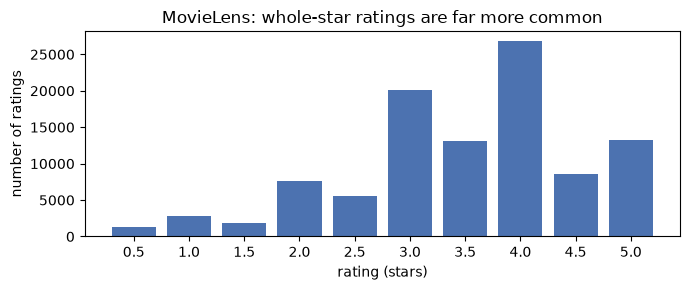

69.9% of ratings are whole stars


In [15]:
dist = sql("SELECT rating, COUNT(*) AS n FROM ratings GROUP BY rating ORDER BY rating")
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(dist["rating"].astype(str), dist["n"], color="#4C72B0")
ax.set(xlabel="rating (stars)", ylabel="number of ratings", title="MovieLens: whole-star ratings are far more common")
plt.tight_layout()
plt.show()
share_whole = dist.loc[dist["rating"] % 1 == 0, "n"].sum() / dist["n"].sum()
print(f"{share_whole:.1%} of ratings are whole stars")

### ✍️ Your Turn

How many **users** have given **at least 1,000 ratings**? Return one number.

In [16]:
query = None  # TODO
check("heavy_users", None if query is None else con.sql(query), 12,
      hint="Group ratings by user_id with HAVING COUNT(*) >= 1000 in a subquery, then COUNT(*) the result.")

⏳ heavy_users: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
SELECT COUNT(*)
FROM (
    SELECT user_id
    FROM ratings
    GROUP BY user_id
    HAVING COUNT(*) >= 1000
)
"""
check("heavy_users", con.sql(query), 12)
```
</details>

> 💡 **Interview angle:** "WHERE vs HAVING?" — `WHERE` filters individual rows before grouping and cannot use aggregates; `HAVING` filters groups after aggregation. Filtering early with `WHERE` is also cheaper because fewer rows reach the `GROUP BY`.

## 5. JOIN Types 🟡

A **join** combines rows from two tables where a condition matches (usually key = key). To see every join type clearly we use two **tiny hand-made tables** (a controlled example), then switch back to real data.

```
students                 enrollments
id | name                student_id | course
 1 | Ana                          1 | SQL
 2 | Ben    (no course)           1 | ML
 3 | Chen                         3 | Stats
                                  4 | Math   (no such student)
```

| Join | Keeps |
|---|---|
| `INNER JOIN` | only matching pairs |
| `LEFT JOIN` | every left row; right columns are NULL when there is no match |
| `RIGHT JOIN` | every right row |
| `FULL OUTER JOIN` | every row from both sides |
| `CROSS JOIN` | every combination (n × m rows) — no condition |

In [17]:
con.sql("CREATE OR REPLACE TABLE students AS SELECT * FROM (VALUES (1, 'Ana'), (2, 'Ben'), (3, 'Chen')) AS t(id, name)")
con.sql("CREATE OR REPLACE TABLE enrollments AS SELECT * FROM (VALUES (1, 'SQL'), (1, 'ML'), (3, 'Stats'), (4, 'Math')) AS t(student_id, course)")

for join in ["INNER JOIN", "LEFT JOIN", "RIGHT JOIN", "FULL OUTER JOIN"]:
    rows = con.sql(f"""
        SELECT s.name, e.course
        FROM students AS s {join} enrollments AS e ON s.id = e.student_id
        ORDER BY s.id NULLS LAST, e.course
    """).fetchall()
    print(f"{join:16s} {len(rows)} rows: {rows}")

n_cross = con.sql("SELECT COUNT(*) FROM students CROSS JOIN enrollments").fetchone()[0]
print(f"{'CROSS JOIN':16s} {n_cross} rows (3 × 4)")

INNER JOIN       3 rows: [('Ana', 'ML'), ('Ana', 'SQL'), ('Chen', 'Stats')]
LEFT JOIN        4 rows: [('Ana', 'ML'), ('Ana', 'SQL'), ('Ben', None), ('Chen', 'Stats')]
RIGHT JOIN       4 rows: [('Ana', 'ML'), ('Ana', 'SQL'), ('Chen', 'Stats'), (None, 'Math')]
FULL OUTER JOIN  5 rows: [('Ana', 'ML'), ('Ana', 'SQL'), ('Ben', None), ('Chen', 'Stats'), (None, 'Math')]
CROSS JOIN       12 rows (3 × 4)


Now real data. A `LEFT JOIN` from `movies` to `ratings` keeps movies that nobody rated. Notice the difference between `COUNT(*)` (counts rows, including the NULL-padded one) and `COUNT(r.movie_id)` (counts only real matches).

In [18]:
sql("""
SELECT m.title,
       COUNT(*)            AS count_star,        -- counts the padded row → 1 for unrated movies
       COUNT(r.movie_id)   AS n_ratings           -- counts non-NULL matches → 0 for unrated movies
FROM movies AS m
LEFT JOIN ratings AS r ON r.movie_id = m.movie_id
GROUP BY m.movie_id, m.title
ORDER BY n_ratings, m.movie_id
LIMIT 4
""")

,title,count_star,n_ratings
0,"Innocents, The (1961)",1,0
1,Niagara (1953),1,0
2,For All Mankind (1989),1,0
3,"Color of Paradise, The (Rang-e khoda) (1999)",1,0


`USING (movie_id)` is a shortcut for `ON a.movie_id = b.movie_id` when both columns share a name (and it outputs the column once).

### ✍️ Your Turn

What is the **average rating of `Forrest Gump (1994)`**, rounded to 2 decimals? Join `ratings` to `movies` and filter by the exact title.

In [19]:
query = None  # TODO
check("gump_avg", None if query is None else con.sql(query), 4.16,
      hint="SELECT ROUND(AVG(rating), 2) FROM ratings JOIN movies USING (movie_id) WHERE title = '...'")

⏳ gump_avg: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
SELECT ROUND(AVG(r.rating), 2)
FROM ratings AS r
JOIN movies AS m USING (movie_id)
WHERE m.title = 'Forrest Gump (1994)'
"""
check("gump_avg", con.sql(query), 4.16)
```
</details>

> 💡 **Interview angle:** Venn diagrams describe joins badly when keys repeat. Say instead: *"an inner join returns every pair of rows whose keys match; a left join also keeps unmatched left rows padded with NULLs."*

## 6. Semi Joins, Anti Joins, and the Duplicate-Key Explosion 🟡

Two very common questions don't want the *columns* of the other table at all:

- **Semi join** — "left rows that have **at least one** match" (never duplicates left rows). Portable SQL: `WHERE EXISTS (...)` or `WHERE key IN (...)`.
- **Anti join** — "left rows that have **no** match". Portable SQL: `WHERE NOT EXISTS (...)` or `LEFT JOIN ... WHERE right.key IS NULL`.

DuckDB also has the keywords `SEMI JOIN` and `ANTI JOIN`.

In [20]:
semi = con.sql("SELECT COUNT(*) FROM movies SEMI JOIN tags USING (movie_id)").fetchone()[0]
exists = con.sql("SELECT COUNT(*) FROM movies AS m WHERE EXISTS (SELECT 1 FROM tags AS t WHERE t.movie_id = m.movie_id)").fetchone()[0]
wrong_inner = con.sql("SELECT COUNT(*) FROM movies AS m JOIN tags AS t USING (movie_id)").fetchone()[0]
print(f"movies with ≥1 tag  → SEMI JOIN: {semi:,} | EXISTS: {exists:,} | plain INNER JOIN (duplicates!): {wrong_inner:,}")

anti = con.sql("SELECT COUNT(*) FROM movies ANTI JOIN ratings USING (movie_id)").fetchone()[0]
left_null = con.sql("""
    SELECT COUNT(*) FROM movies AS m
    LEFT JOIN ratings AS r ON r.movie_id = m.movie_id
    WHERE r.movie_id IS NULL
""").fetchone()[0]
print(f"movies nobody rated → ANTI JOIN: {anti} | LEFT JOIN … IS NULL: {left_null}")

movies with ≥1 tag  → SEMI JOIN: 1,572 | EXISTS: 1,572 | plain INNER JOIN (duplicates!): 3,683
movies nobody rated → ANTI JOIN: 18 | LEFT JOIN … IS NULL: 18


### 💥 The duplicate-key explosion

If a key appears **a** times on the left and **b** times on the right, the join outputs **a × b** rows for that key. Joining two tables that are *both* many-per-movie multiplies rows — and silently inflates `SUM` and `COUNT`.

In [21]:
n_ratings = con.sql("SELECT COUNT(*) FROM ratings").fetchone()[0]
n_tags = con.sql("SELECT COUNT(*) FROM tags").fetchone()[0]
n_joined = con.sql("SELECT COUNT(*) FROM ratings JOIN tags USING (movie_id)").fetchone()[0]
predicted = con.sql("""
    SELECT SUM(r.n * t.n)
    FROM (SELECT movie_id, COUNT(*) AS n FROM ratings GROUP BY movie_id) AS r
    JOIN (SELECT movie_id, COUNT(*) AS n FROM tags GROUP BY movie_id) AS t USING (movie_id)
""").fetchone()[0]
print(f"ratings: {n_ratings:,} rows | tags: {n_tags:,} rows | ratings ⨝ tags on movie_id: {n_joined:,} rows")
print(f"Σ (ratings per movie × tags per movie) = {predicted:,} → matches: {predicted == n_joined}")

sql("""
SELECT 'ratings only'        AS source, COUNT(*) AS n_rows, SUM(rating) AS total_stars, ROUND(AVG(rating), 3) AS avg_rating
FROM ratings WHERE movie_id = 296
UNION ALL
SELECT 'ratings ⨝ tags', COUNT(*), SUM(r.rating), ROUND(AVG(r.rating), 3)
FROM ratings AS r JOIN tags AS t USING (movie_id) WHERE movie_id = 296
""")

ratings: 100,836 rows | tags: 3,683 rows | ratings ⨝ tags on movie_id: 233,213 rows
Σ (ratings per movie × tags per movie) = 233,213 → matches: True


,source,n_rows,total_stars,avg_rating
0,ratings only,307,1288.5,4.197
1,ratings ⨝ tags,55567,233218.5,4.197


For *Pulp Fiction* (`movie_id = 296`), `COUNT` and `SUM` are multiplied by its number of tag rows, while `AVG` happens to survive (every rating is copied the same number of times). **Fix:** aggregate each table to the join key *first*, then join.

### ✍️ Your Turn

Count the movies in `movies` that have **never been rated**. Use an anti join (either DuckDB's `ANTI JOIN` or portable `NOT EXISTS`).

In [22]:
query = None  # TODO
check("never_rated", None if query is None else con.sql(query), 18,
      hint="SELECT COUNT(*) FROM movies AS m WHERE NOT EXISTS (SELECT 1 FROM ratings AS r WHERE r.movie_id = m.movie_id)")

⏳ never_rated: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
SELECT COUNT(*)
FROM movies AS m
WHERE NOT EXISTS (SELECT 1 FROM ratings AS r WHERE r.movie_id = m.movie_id)
"""
check("never_rated", con.sql(query), 18)
```

`SELECT COUNT(*) FROM movies ANTI JOIN ratings USING (movie_id)` gives the same answer in DuckDB.
</details>

> 💡 **Interview angle:** "Revenue doubled after I added a join — why?" — the join key was not unique on one side (fan-out). Check `COUNT(*)` vs `COUNT(DISTINCT key)` on each side, and aggregate before joining.

## 7. NULL Semantics 🟡

`NULL` means **unknown / missing** — not zero, not an empty string. Any comparison with an unknown value is itself **unknown**. SQL therefore uses **three-valued logic**: `TRUE`, `FALSE`, `UNKNOWN` (shown as NULL).

| Rule | Consequence |
|---|---|
| `NULL = NULL` is NULL, not TRUE | use `IS NULL` / `IS NOT DISTINCT FROM` |
| `WHERE` keeps only TRUE rows | rows where the condition is UNKNOWN disappear |
| `COUNT(*)` counts rows; `COUNT(col)` skips NULLs | the two can differ |
| `SUM`/`AVG`/`MIN`/`MAX` ignore NULLs | `AVG(col)` ≠ `SUM(col) / COUNT(*)` |
| `x NOT IN (…, NULL)` is never TRUE | returns **zero rows** |
| `GROUP BY` puts all NULLs in **one** group | |

In [23]:
sql("""
SELECT
    NULL = NULL                     AS null_eq_null,
    NULL IS NULL                    AS null_is_null,
    NULL IS NOT DISTINCT FROM NULL  AS null_not_distinct,
    TRUE AND NULL                   AS true_and_null,
    FALSE AND NULL                  AS false_and_null,   -- FALSE: the unknown can't make it TRUE
    TRUE OR NULL                    AS true_or_null,     -- TRUE: already true either way
    3 NOT IN (1, 2)                 AS not_in_plain,
    3 NOT IN (1, NULL)              AS not_in_with_null  -- NULL: "is 3 ≠ unknown?" is unknown
""")

,null_eq_null,null_is_null,null_not_distinct,true_and_null,false_and_null,true_or_null,not_in_plain,not_in_with_null
0,<NA>,True,True,<NA>,False,True,True,<NA>


Real data: 8 rows of `links` have no TMDB id.

In [24]:
sql("""
SELECT
    COUNT(*)                                     AS all_rows,
    COUNT(tmdb_id)                               AS rows_with_tmdb_id,
    COUNT(*) FILTER (WHERE tmdb_id <> 862)       AS "tmdb_id <> 862",          -- NULL rows vanish here…
    COUNT(*) FILTER (WHERE tmdb_id IS DISTINCT FROM 862) AS "IS DISTINCT FROM 862",  -- …but are kept here
    COUNT(COALESCE(tmdb_id, -1))                 AS after_coalesce
FROM links
""")

,all_rows,rows_with_tmdb_id,tmdb_id <> 862,IS DISTINCT FROM 862,after_coalesce
0,9742,9734,9733,9741,9742


In [25]:
# NULLs in aggregates and sorting (a controlled example)
sql("""
SELECT
    COUNT(*)                         AS count_star,
    COUNT(x)                         AS count_x,
    AVG(x)                           AS avg_ignores_nulls,
    SUM(x) / COUNT(*)                AS sum_over_all_rows,
    list(x ORDER BY x DESC)          AS sorted_desc              -- DuckDB puts NULLs last by default
FROM (VALUES (1), (NULL), (3)) AS t(x)
""")

,count_star,count_x,avg_ignores_nulls,sum_over_all_rows,sorted_desc
0,3,2,2.0,1.333333,"[3, 1, --]"


Sorting NULLs differs by database (Postgres puts NULLs *first* for `DESC`). When it matters, say it explicitly: `ORDER BY x DESC NULLS LAST`.

### ✍️ Your Turn

Using **only aggregate functions** (no `WHERE`), return how many rows of `links` have a missing `tmdb_id`.

In [26]:
query = None  # TODO
check("missing_tmdb", None if query is None else con.sql(query), 8,
      hint="COUNT(*) counts every row and COUNT(tmdb_id) skips NULLs — subtract.")

⏳ missing_tmdb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = "SELECT COUNT(*) - COUNT(tmdb_id) FROM links"
check("missing_tmdb", con.sql(query), 8)
```

`SUM(CASE WHEN tmdb_id IS NULL THEN 1 ELSE 0 END)` and `COUNT(*) FILTER (WHERE tmdb_id IS NULL)` also work.
</details>

> 💡 **Interview angle:** "Why did `WHERE id NOT IN (SELECT ...)` return nothing?" — the subquery contains a NULL, so every `NOT IN` test is UNKNOWN. Use `NOT EXISTS` (NULL-safe) or filter NULLs out of the subquery.

## 8. Subqueries vs CTEs 🟡

A **subquery** is a query inside another query. A **CTE** (Common Table Expression, `WITH name AS (...)`) gives a subquery a name so the main query reads top-to-bottom like a recipe.

| Kind | Example use |
|---|---|
| Scalar subquery (returns one value) | `WHERE rating > (SELECT AVG(rating) FROM ratings)` |
| `IN` / `EXISTS` subquery | semi/anti joins |
| Correlated subquery (refers to the outer row) | "ratings above *this user's* average" |
| Derived table (subquery in `FROM`) | aggregate first, then filter |
| CTE (`WITH`) | same as a derived table, but named and reusable |

In [27]:
# Question: which movies (≥ 100 ratings) are rated above the overall average? Three equivalent ways.
nested = """
SELECT title, avg_rating
FROM (
    SELECT m.title, AVG(r.rating) AS avg_rating, COUNT(*) AS n
    FROM ratings AS r JOIN movies AS m USING (movie_id)
    GROUP BY m.title
) AS per_movie
WHERE n >= 100 AND avg_rating > (SELECT AVG(rating) FROM ratings)
ORDER BY avg_rating DESC, title
"""

with_cte = """
WITH per_movie AS (
    SELECT m.title, AVG(r.rating) AS avg_rating, COUNT(*) AS n
    FROM ratings AS r JOIN movies AS m USING (movie_id)
    GROUP BY m.title
),
overall AS (
    SELECT AVG(rating) AS avg_all FROM ratings
)
SELECT per_movie.title, per_movie.avg_rating
FROM per_movie CROSS JOIN overall
WHERE per_movie.n >= 100 AND per_movie.avg_rating > overall.avg_all
ORDER BY avg_rating DESC, title
"""

a, b = con.sql(nested).fetchall(), con.sql(with_cte).fetchall()
print(f"nested subquery rows: {len(a)} | CTE rows: {len(b)} | identical: {a == b}")
print("top 3:", [(t, round(v, 2)) for t, v in a[:3]])

nested subquery rows: 110 | CTE rows: 110 | identical: True


top 3: [('Shawshank Redemption, The (1994)', 4.43), ('Godfather, The (1972)', 4.29), ('Fight Club (1999)', 4.27)]


In [28]:
# Correlated subquery: for each user, how many of their ratings are above THEIR OWN average?
sql("""
SELECT r.user_id, COUNT(*) AS n_above_own_avg
FROM ratings AS r
WHERE r.rating > (SELECT AVG(r2.rating) FROM ratings AS r2 WHERE r2.user_id = r.user_id)
GROUP BY r.user_id
ORDER BY n_above_own_avg DESC
LIMIT 3
""")

,user_id,n_above_own_avg
0,414,1459
1,474,1367
2,599,1104


**Performance note:** modern optimizers (DuckDB, Postgres 12+) usually inline CTEs and "decorrelate" correlated subqueries into joins, so choose the version that is easiest to read. A correlated subquery is *logically* re-evaluated per row — in engines that can't decorrelate it, it can be very slow.

### ✍️ Your Turn

Using a **CTE**, count the users whose **average rating is above the overall average rating** (the average over all rating rows).

In [29]:
query = None  # TODO
check("users_above_avg", None if query is None else con.sql(query), 397,
      hint="WITH per_user AS (SELECT user_id, AVG(rating) AS a FROM ratings GROUP BY user_id) SELECT COUNT(*) FROM per_user WHERE a > (SELECT ...)")

⏳ users_above_avg: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
WITH per_user AS (
    SELECT user_id, AVG(rating) AS avg_rating
    FROM ratings
    GROUP BY user_id
)
SELECT COUNT(*)
FROM per_user
WHERE avg_rating > (SELECT AVG(rating) FROM ratings)
"""
check("users_above_avg", con.sql(query), 397)
```

Note the subtle point: the overall average over *ratings* weights heavy raters more than the average of *user averages* would.
</details>

> 💡 **Interview angle:** "CTE or subquery?" — same result; CTEs win on readability and let you reference a step twice. In interviews, build the answer as a chain of small CTEs and test each step — it's easier to debug out loud.

## 9. Window Functions: Ranking, Top-N, Percent of Total 🟡

`GROUP BY` **collapses** rows: one output row per group. A **window function** **keeps every row** and adds a column computed over a *window* of related rows.

```
GROUP BY genre                         window: COUNT(*) OVER (PARTITION BY genre)
genre   | n                            title | genre  | n_in_genre
Comedy  | 2          (rows gone)       A     | Comedy | 2
Drama   | 1                            B     | Comedy | 2      (every row kept)
                                       C     | Drama  | 1
```

Syntax: `function() OVER (PARTITION BY group_cols ORDER BY sort_cols [frame])`
- `PARTITION BY` = which rows belong together (like GROUP BY, but nothing collapses)
- `ORDER BY` = order inside each partition (needed for ranks, LAG, running totals)

| Function | Ties 90, 85, 85, 80 get |
|---|---|
| `ROW_NUMBER()` | 1, 2, 3, 4 (ties broken arbitrarily — add a tiebreaker!) |
| `RANK()` | 1, 2, 2, **4** (gaps after ties) |
| `DENSE_RANK()` | 1, 2, 2, **3** (no gaps) |

In [30]:
sql("""
SELECT player, score,
       ROW_NUMBER() OVER (ORDER BY score DESC, player) AS row_number,
       RANK()       OVER (ORDER BY score DESC)         AS rank,
       DENSE_RANK() OVER (ORDER BY score DESC)         AS dense_rank
FROM (VALUES ('A', 90), ('B', 85), ('C', 85), ('D', 80)) AS t(player, score)
ORDER BY score DESC, player
""")

,player,score,row_number,rank,dense_rank
0,A,90,1,1,1
1,B,85,2,2,2
2,C,85,3,2,2
3,D,80,4,4,3


**Top-N per group** — the most common window-function interview question. Example: the 3 most-rated movies in each of three genres.
Step 1: compute a rank inside each partition. Step 2: keep rank ≤ 3. Window functions run *after* `WHERE`, so the filter goes in an outer query — or in DuckDB's `QUALIFY` clause (also in Snowflake, BigQuery, Databricks).

In [31]:
top3_portable = """
WITH genre_movie AS (
    SELECT g.genre, m.title, COUNT(*) AS n_ratings
    FROM ratings AS r
    JOIN (SELECT movie_id, unnest(string_split(genres, '|')) AS genre FROM movies) AS g USING (movie_id)
    JOIN movies AS m USING (movie_id)
    WHERE g.genre IN ('Animation', 'Horror', 'Documentary')
    GROUP BY g.genre, m.title
),
ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY genre ORDER BY n_ratings DESC, title) AS rn
    FROM genre_movie
)
SELECT genre, rn, title, n_ratings FROM ranked WHERE rn <= 3 ORDER BY genre, rn
"""
top3_qualify = """
SELECT g.genre, m.title, COUNT(*) AS n_ratings
FROM ratings AS r
JOIN (SELECT movie_id, unnest(string_split(genres, '|')) AS genre FROM movies) AS g USING (movie_id)
JOIN movies AS m USING (movie_id)
WHERE g.genre IN ('Animation', 'Horror', 'Documentary')
GROUP BY g.genre, m.title
QUALIFY ROW_NUMBER() OVER (PARTITION BY g.genre ORDER BY COUNT(*) DESC, m.title) <= 3
ORDER BY g.genre, n_ratings DESC, m.title
"""
portable_rows = [(g, t, n) for g, _, t, n in con.sql(top3_portable).fetchall()]
print("QUALIFY version gives the same rows:", portable_rows == con.sql(top3_qualify).fetchall())
sql(top3_portable)

QUALIFY version gives the same rows: True


,genre,rn,title,n_ratings
0,Animation,1,Toy Story (1995),215
1,Animation,2,Aladdin (1992),183
2,Animation,3,"Lion King, The (1994)",172
3,Documentary,1,Bowling for Columbine (2002),58
4,Documentary,2,Super Size Me (2004),50
5,Documentary,3,Fahrenheit 9/11 (2004),37
6,Horror,1,"Silence of the Lambs, The (1991)",279
7,Horror,2,"Sixth Sense, The (1999)",179
8,Horror,3,Alien (1979),146


**Percent of total** — an aggregate with an *empty* window `OVER ()` sees the whole result, so each row can be divided by the grand total.

In [32]:
sql("""
SELECT genre,
       COUNT(*) AS n_ratings,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_all_genre_ratings
FROM ratings
JOIN (SELECT movie_id, unnest(string_split(genres, '|')) AS genre FROM movies) USING (movie_id)
GROUP BY genre
ORDER BY n_ratings DESC
LIMIT 6
""")

,genre,n_ratings,pct_of_all_genre_ratings
0,Drama,41928,15.28
1,Comedy,39053,14.23
2,Action,30635,11.16
3,Thriller,26452,9.64
4,Adventure,24161,8.80
5,Romance,18124,6.60


`SUM(COUNT(*)) OVER ()` looks odd but follows the execution order: `GROUP BY` produces `COUNT(*)` per genre first, then the window sums those counts.

### ✍️ Your Turn

For each **calendar year from 2015 on** (use the year of `rated_at`), return the single **most-rated movie that year**: columns `year, title, n_ratings`, one row per year, sorted by year. Break ties by title (alphabetical).

In [33]:
query = None  # TODO
check("top_movie_per_year", None if query is None else con.sql(query),
      [(2015, "Matrix, The (1999)", 35), (2016, "Matrix, The (1999)", 24),
       (2017, "Shawshank Redemption, The (1994)", 31), (2018, "Matrix, The (1999)", 19)],
      hint="Count per (year, title) in a CTE, then ROW_NUMBER() OVER (PARTITION BY year ORDER BY n_ratings DESC, title) = 1.")

⏳ top_movie_per_year: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
WITH per_year AS (
    SELECT year(r.rated_at) AS year, m.title, COUNT(*) AS n_ratings
    FROM ratings AS r JOIN movies AS m USING (movie_id)
    WHERE year(r.rated_at) >= 2015
    GROUP BY year, m.title
)
SELECT year, title, n_ratings
FROM per_year
QUALIFY ROW_NUMBER() OVER (PARTITION BY year ORDER BY n_ratings DESC, title) = 1
ORDER BY year
"""
check("top_movie_per_year", con.sql(query),
      [(2015, "Matrix, The (1999)", 35), (2016, "Matrix, The (1999)", 24),
       (2017, "Shawshank Redemption, The (1994)", 31), (2018, "Matrix, The (1999)", 19)])
```

Use `RANK()` instead of `ROW_NUMBER()` if the question says "return all movies tied for first".
</details>

> 💡 **Interview angle:** "Top 3 per department" → `ROW_NUMBER()`/`RANK()`/`DENSE_RANK()` `OVER (PARTITION BY dept ORDER BY salary DESC)` then filter in an outer query. Always ask how ties should be handled — that decides which ranking function is correct.

## 10. Window Functions: LAG/LEAD, Running Totals, Moving Averages 🔴

- `LAG(col, k)` = value **k rows before** in the partition; `LEAD(col, k)` = **k rows after**. Great for "time since previous event".
- Aggregates with `ORDER BY` inside `OVER` become **running** aggregates.
- A **frame** says exactly which rows around the current one are included:

```
ROWS BETWEEN 2 PRECEDING AND CURRENT ROW        → the current row + 2 rows before  (3-row moving window)
ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW → everything so far                (running total)
RANGE BETWEEN INTERVAL 6 DAYS PRECEDING AND CURRENT ROW → by VALUE of the ORDER BY column (7 calendar days)
```

⚠️ With `ORDER BY` but **no frame**, the default is `RANGE BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW` — rows **tied** on the ORDER BY value are all included together (see Pitfalls).

     month   n  running_total  moving_avg_12  change_vs_prev_month
2018-06-01 419        99108.0     541.333333                  -532
2018-07-01 293        99401.0     551.583333                  -126
2018-08-01 831       100232.0     602.416667                   538
2018-09-01 604       100836.0     617.416667                  -227


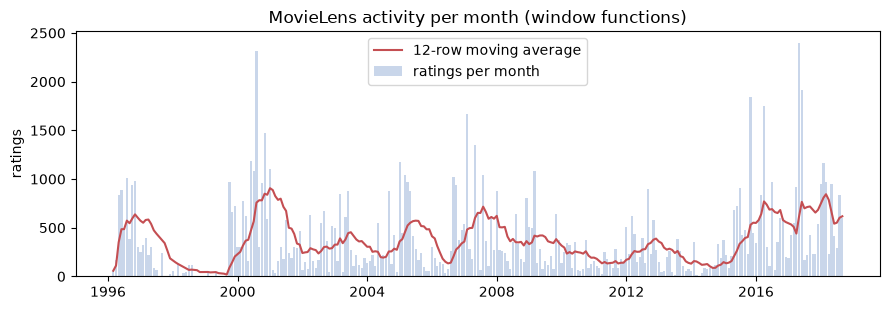

In [34]:
# Monthly platform activity: running total and a 12-month moving average
monthly = sql("""
WITH months AS (
    SELECT date_trunc('month', rated_at) AS month, COUNT(*) AS n
    FROM ratings
    GROUP BY month
)
SELECT month, n,
       SUM(n) OVER (ORDER BY month ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS running_total,
       AVG(n) OVER (ORDER BY month ROWS BETWEEN 11 PRECEDING AND CURRENT ROW)       AS moving_avg_12,
       n - LAG(n) OVER (ORDER BY month)                                             AS change_vs_prev_month
FROM months
ORDER BY month
""")
print(monthly.tail(4).to_string(index=False))
assert monthly["running_total"].iloc[-1] == n_ratings            # the running total ends at the table size

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(monthly["month"], monthly["n"], width=25, color="#C9D6EA", label="ratings per month")
ax.plot(monthly["month"], monthly["moving_avg_12"], color="#C44E52", label="12-row moving average")
ax.set(ylabel="ratings", title="MovieLens activity per month (window functions)")
ax.legend()
plt.tight_layout()
plt.show()

Months with zero ratings have **no row**, so "12 rows preceding" is not always "12 calendar months". Section 11 shows how to fill missing months first.

In [35]:
# LAG per user: days between consecutive distinct rating days
sql("""
WITH days AS (SELECT DISTINCT user_id, CAST(rated_at AS DATE) AS day FROM ratings)
SELECT user_id, day,
       LAG(day)  OVER (PARTITION BY user_id ORDER BY day)        AS previous_day,
       day - LAG(day) OVER (PARTITION BY user_id ORDER BY day)   AS days_since_previous,
       LEAD(day) OVER (PARTITION BY user_id ORDER BY day)        AS next_day
FROM days
WHERE user_id = 387
ORDER BY day
LIMIT 5
""")

,user_id,day,previous_day,days_since_previous,next_day
0,387,2004-09-10,NaT,<NA>,2004-09-11
1,387,2004-09-11,2004-09-10,1,2004-09-13
2,387,2004-09-13,2004-09-11,2,2004-09-14
3,387,2004-09-14,2004-09-13,1,2004-09-16
4,387,2004-09-16,2004-09-14,2,2004-09-18


### ✍️ Your Turn

User **414** is the most active rater. Considering only their **distinct rating days**, what is the **longest gap in days** between two consecutive rating days? Return one number.

In [36]:
query = None  # TODO
check("max_gap_414", None if query is None else con.sql(query), 1488,
      hint="Window functions can't be nested inside MAX directly: compute day - LAG(day) OVER (ORDER BY day) in a subquery, then take MAX outside.")

⏳ max_gap_414: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
WITH days AS (
    SELECT DISTINCT CAST(rated_at AS DATE) AS day FROM ratings WHERE user_id = 414
),
gaps AS (
    SELECT day - LAG(day) OVER (ORDER BY day) AS gap FROM days
)
SELECT MAX(gap) FROM gaps
"""
check("max_gap_414", con.sql(query), 1488)
```

Writing `MAX(day - LAG(day) OVER (...))` in one step fails with *"aggregate function calls cannot contain window function calls"* — windows are evaluated after aggregates.
</details>

> 💡 **Interview angle:** "7-day rolling average of daily revenue" → first build one row per calendar day (fill gaps with 0), then `AVG(revenue) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)`. Mention that `ROWS` counts rows while `RANGE` uses values — with missing days they give different answers.

## 11. Dates and Time Bucketing 🟡

Time is the most common dimension in analytics and ML features.

| Task | DuckDB | Notes |
|---|---|---|
| Unix seconds → timestamp | `make_timestamp(sec * 1000000)` / `to_timestamp(sec)` | `to_timestamp` returns a time-zone-aware type |
| Truncate to a period | `date_trunc('month', ts)` | also `'day'`, `'week'`, `'year'` |
| Fixed-width buckets | `time_bucket(INTERVAL '15 minutes', ts)` | any interval |
| Parts | `year(ts)`, `month(ts)`, `dayname(ts)`, `extract('hour' FROM ts)` | |
| Differences | `date_diff('day', start, end)` | counts **boundaries crossed** |
| Arithmetic | `ts + INTERVAL 30 DAY`, `date - date` → days | |
| Calendar of periods | `generate_series(start, stop, INTERVAL 1 MONTH)` | fill missing periods |

In [37]:
sql("""
SELECT
    rated_at,
    CAST(rated_at AS DATE)                          AS day,
    date_trunc('month', rated_at)                   AS month_start,
    time_bucket(INTERVAL '1 week', rated_at)        AS week_bucket,        -- weeks start on Monday
    dayname(rated_at)                               AS weekday,
    extract('hour' FROM rated_at)                   AS hour_utc,
    rated_at + INTERVAL 30 DAY                      AS plus_30_days
FROM ratings
WHERE user_id = 1
ORDER BY rated_at
LIMIT 3
""")

,rated_at,day,month_start,week_bucket,weekday,hour_utc,plus_30_days
0,2000-07-30 18:08:19,2000-07-30,2000-07-01,2000-07-24,Sunday,18,2000-08-29 18:08:19
1,2000-07-30 18:08:19,2000-07-30,2000-07-01,2000-07-24,Sunday,18,2000-08-29 18:08:19
2,2000-07-30 18:08:43,2000-07-30,2000-07-01,2000-07-24,Sunday,18,2000-08-29 18:08:43


In [38]:
# Fill missing months with a calendar table, then LEFT JOIN activity onto it
calendar_fill = sql("""
WITH bounds AS (
    SELECT date_trunc('month', MIN(rated_at)) AS lo, date_trunc('month', MAX(rated_at)) AS hi FROM ratings
),
calendar AS (
    SELECT unnest(generate_series(lo, hi, INTERVAL 1 MONTH)) AS month FROM bounds
),
activity AS (
    SELECT date_trunc('month', rated_at) AS month, COUNT(*) AS n FROM ratings GROUP BY month
)
SELECT c.month, COALESCE(a.n, 0) AS n_ratings
FROM calendar AS c LEFT JOIN activity AS a USING (month)
ORDER BY c.month
""")
empty = calendar_fill[calendar_fill["n_ratings"] == 0]
print(f"{len(calendar_fill)} calendar months, {len(empty)} with zero ratings:",
      [m.strftime("%Y-%m") for m in empty["month"]])

271 calendar months, 4 with zero ratings: ['1997-08', '1998-04', '1998-09', '1999-04']


In [39]:
# date_diff counts boundaries: Jan 31 → Feb 1 is "1 month" even though only 1 day passed
sql("""
SELECT date_diff('month', DATE '2024-01-31', DATE '2024-02-01') AS months_diff,
       date_diff('day',   DATE '2024-01-31', DATE '2024-02-01') AS days_diff,
       DATE '2024-03-01' - DATE '2024-02-01'                     AS leap_february_days
""")

,months_diff,days_diff,leap_february_days
0,1,1,29


### ✍️ Your Turn

Which **calendar month** had the most ratings? Return one row: `month_text` formatted as `'YYYY-MM'` and `n_ratings`.

In [40]:
query = None  # TODO
check("busiest_month", None if query is None else con.sql(query), [("2017-05", 2397)],
      hint="strftime(date_trunc('month', rated_at), '%Y-%m'), GROUP BY it, ORDER BY count DESC, LIMIT 1.")

⏳ busiest_month: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
SELECT strftime(date_trunc('month', rated_at), '%Y-%m') AS month_text, COUNT(*) AS n_ratings
FROM ratings
GROUP BY month_text
ORDER BY n_ratings DESC
LIMIT 1
"""
check("busiest_month", con.sql(query), [("2017-05", 2397)])
```
</details>

> 💡 **Interview angle:** Always ask *"which time zone?"* and *"are the buckets calendar-based or rolling?"* Storing timestamps in UTC and converting at the edges avoids daylight-saving bugs in daily aggregates.

## 12. Querying pandas and Parquet Directly 🟢

DuckDB can query data **where it already lives**:

- a **pandas DataFrame** in memory — just use the variable name in `FROM` (a "replacement scan"; no copy for most column types)
- **CSV / Parquet / JSON files** — `FROM 'file.parquet'` or `read_parquet('folder/*.parquet')`
- and return results as pandas (`.df()`), Polars (`.pl()`), Arrow (`.arrow()`) or NumPy (`.fetchnumpy()`)

**Parquet** is a compressed, **columnar** file format: values of each column are stored together, with min/max statistics per chunk. Analytics engines read only the columns and chunks a query needs.

In [41]:
# A pandas DataFrame, created the pandas way…
movies_df = pd.read_csv(DATA_DIR / "movies.csv")
movies_df["is_comedy"] = movies_df["genres"].str.contains("Comedy")

# …queried with SQL by its Python variable name
duckdb_on_pandas = con.sql("""
    SELECT is_comedy, COUNT(*) AS n_movies
    FROM movies_df
    GROUP BY is_comedy
    ORDER BY is_comedy
""").df()
print(duckdb_on_pandas)
print("result type:", type(duckdb_on_pandas).__name__)

   is_comedy  n_movies
0      False      5986
1       True      3756
result type: DataFrame


In [42]:
# Write Parquet with COPY, then compare file sizes and query the file directly
parquet_path = OUTPUT_DIR / "ratings.parquet"
con.sql(f"COPY ratings TO '{parquet_path}' (FORMAT parquet)")
csv_mb = (DATA_DIR / "ratings.csv").stat().st_size / 1e6
parquet_mb = parquet_path.stat().st_size / 1e6
print(f"ratings.csv: {csv_mb:.2f} MB | ratings.parquet: {parquet_mb:.2f} MB ({csv_mb / parquet_mb:.1f}× smaller, and types are kept)")

print(con.sql(f"""
    SELECT year(rated_at) AS year, COUNT(*) AS n, ROUND(AVG(rating), 3) AS avg_rating
    FROM '{parquet_path}'
    WHERE rated_at >= TIMESTAMP '2016-01-01'
    GROUP BY year ORDER BY year
""").df())

ratings.csv: 2.48 MB | ratings.parquet: 0.89 MB (2.8× smaller, and types are kept)


   year     n  avg_rating
0  2016  6703       3.686
1  2017  8198       3.349
2  2018  6418       3.389


You can also query a CSV without creating a table, e.g. `FROM '_outputs/ml-latest-small/tags.csv'` — convenient for a first look at a new file.

> 💡 **Interview angle:** "Why Parquet instead of CSV for ML data?" — columnar and compressed (smaller, faster to scan few columns), keeps types (no re-parsing dates), and has per-chunk statistics that let engines skip data. CSV is only better for human readability and universal compatibility.

## 13. EXPLAIN, Indexes, and Partitioning 🟡

`EXPLAIN query` shows the **plan** the optimizer chose — a tree of operators. Read it **bottom-up**: scans at the bottom feed filters, joins and aggregates above. `EXPLAIN ANALYZE` actually runs the query and adds real row counts and timings.

What to look for:
- **Filter / projection pushdown** — filters and column lists applied *inside* the scan, so less data flows upward.
- **Join type** — `HASH_JOIN` (build a hash table on one side) is the workhorse; a nested-loop join on big inputs is a red flag.
- **Estimated vs actual rows** — big mismatches mean the optimizer guessed badly.

In [43]:
plan = con.sql("""
EXPLAIN
SELECT m.title, COUNT(*) AS n
FROM ratings AS r JOIN movies AS m USING (movie_id)
WHERE r.rating = 5
GROUP BY m.title
""").fetchall()[0][1]
print(plan)

┌───────────────────────────┐
│       HASH_GROUP_BY       │
│    ────────────────────   │
│         Groups: #0        │
│                           │
│        Aggregates:        │
│        count_star()       │
│                           │
│          ~11 rows         │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│           title           │
│                           │
│        ~11,683 rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│             #0            │
│__internal_compress_integra│
│     l_uinteger(#1, 1)     │
│                           │
│        ~11,683 rows       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         HASH_JOIN         │
│    ────────────────────   │
│      Join Type: INNER     │
│                           │
│        Conditions:        ├──────────────┐
│    movie_id = movie_id 

### Indexes vs partitions (the concept interviewers want)

| | **Row-store OLTP** (Postgres, MySQL) | **Columnar OLAP** (DuckDB, BigQuery, Snowflake, Parquet) |
|---|---|---|
| Typical query | fetch/update *a few* rows by key | scan *millions* of rows, few columns |
| Main speed-up | **B-tree index**: jump to matching rows in O(log n) | **column pruning** + **zone maps** (min/max per chunk) + **partition pruning** |
| Cost | every index slows writes and uses space | data layout matters: sort/partition by common filters |

**Partitioning** splits data into folders by a column (e.g. `year=2018/`). A query filtering on that column can skip whole files. Let's measure it.

In [44]:
partitioned_dir = OUTPUT_DIR / "ratings_by_year"
con.sql(f"""
COPY (SELECT *, year(rated_at) AS year FROM ratings)
TO '{partitioned_dir}' (FORMAT parquet, PARTITION_BY (year), OVERWRITE_OR_IGNORE)
""")
folders = sorted(p.name for p in partitioned_dir.iterdir())
print(f"{len(folders)} partition folders, e.g. {folders[:3]} … {folders[-1]}")

pruned_plan = con.sql(f"""
EXPLAIN ANALYZE
SELECT COUNT(*) FROM read_parquet('{partitioned_dir}/*/*.parquet', hive_partitioning = true)
WHERE year = 2018
""").fetchall()[0][1]
scan_lines = [line.strip("│ ").strip() for line in pruned_plan.splitlines()
              if line.startswith("│") and re.search(r"Files|Filters|\(year = ", line)]
print("From EXPLAIN ANALYZE:", [line for line in scan_lines if line])

23 partition folders, e.g. ['year=1996', 'year=1997', 'year=1998'] … year=2018
From EXPLAIN ANALYZE: ['File Filters:', '(year = 2018)', 'Scanning Files: 1/23', 'Total Files Read: 1']


`Scanning Files: 1/23` means DuckDB opened only the `year=2018` folder. On a data lake with years of daily partitions, this is the difference between reading megabytes and terabytes.

**Why not "just add indexes" in DuckDB?** DuckDB does support `CREATE INDEX` (ART indexes) — mainly to enforce `PRIMARY KEY`/`UNIQUE` constraints and speed up very selective point lookups. For analytical scans, zone maps and partitions matter far more.

> 💡 **Interview angle:** "This dashboard query is slow — what do you check?" — run `EXPLAIN ANALYZE`; confirm filters are pushed into the scan; partition or cluster by the common filter column (usually date); select only needed columns; pre-aggregate if it runs often; in an OLTP database, add an index matching the `WHERE`/`JOIN` columns.

## 14. SQL ↔ pandas Translation 🟡

| SQL | pandas |
|---|---|
| `SELECT a, b FROM df WHERE a > 1` | `df.loc[df.a > 1, ["a", "b"]]` |
| `ORDER BY a DESC LIMIT 5` | `df.sort_values("a", ascending=False).head(5)` |
| `GROUP BY k` + `COUNT(*)`, `AVG(x)` | `df.groupby("k").agg(n=("x", "size"), avg=("x", "mean"))` |
| `HAVING COUNT(*) >= 50` | `.query("n >= 50")` after the groupby |
| `LEFT JOIN t USING (k)` | `df.merge(t, on="k", how="left")` |
| anti join | `merge(..., how="left", indicator=True)` then `_merge == "left_only"` |
| `ROW_NUMBER() OVER (PARTITION BY k ORDER BY x DESC)` | `df.sort_values("x", ascending=False).groupby("k").cumcount() + 1` |
| `DENSE_RANK() OVER (PARTITION BY k ORDER BY x DESC)` | `df.groupby("k")["x"].rank(method="dense", ascending=False)` |
| `AVG(x) OVER (… ROWS 2 PRECEDING)` | `df.groupby("k")["x"].rolling(3, min_periods=1).mean()` |
| `LAG(x) OVER (PARTITION BY k ORDER BY t)` | `df.sort_values("t").groupby("k")["x"].shift(1)` |

Let's prove a few translations produce identical results.

In [45]:
ratings_df = con.sql("SELECT * FROM ratings").df()
movies_pd = con.sql("SELECT * FROM movies").df()

# 1) GROUP BY + HAVING + ORDER BY
sql_result = con.sql("""
    SELECT movie_id, COUNT(*) AS n, AVG(rating) AS avg_rating
    FROM ratings_df GROUP BY movie_id HAVING COUNT(*) >= 200
    ORDER BY n DESC, movie_id
""").df()
pd_result = (ratings_df.groupby("movie_id", as_index=False)
             .agg(n=("rating", "size"), avg_rating=("rating", "mean"))
             .query("n >= 200")
             .sort_values(["n", "movie_id"], ascending=[False, True])
             .reset_index(drop=True))
pd.testing.assert_frame_equal(sql_result, pd_result, check_dtype=False)
print(f"1) GROUP BY/HAVING: identical ({len(sql_result)} movies)")

# 2) Top-1 per user with ROW_NUMBER vs cumcount (latest rating, ties broken by movie_id)
sql_latest = con.sql("""
    SELECT user_id, movie_id, rated_at FROM ratings_df
    QUALIFY ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY rated_at DESC, movie_id) = 1
    ORDER BY user_id
""").df()
ordered = ratings_df.sort_values(["user_id", "rated_at", "movie_id"], ascending=[True, False, True])
pd_latest = (ordered[ordered.groupby("user_id").cumcount() == 0][["user_id", "movie_id", "rated_at"]]
             .sort_values("user_id").reset_index(drop=True))
pd.testing.assert_frame_equal(sql_latest, pd_latest, check_dtype=False)
print(f"2) ROW_NUMBER top-1 per group: identical ({len(sql_latest)} users)")

# 3) LEFT JOIN
sql_join = con.sql("""
    SELECT m.movie_id, m.title, COUNT(r.rating) AS n_ratings
    FROM movies_pd AS m LEFT JOIN ratings_df AS r USING (movie_id)
    GROUP BY m.movie_id, m.title ORDER BY m.movie_id
""").df()
pd_join = (movies_pd.merge(ratings_df, on="movie_id", how="left")
           .groupby(["movie_id", "title"], as_index=False)
           .agg(n_ratings=("rating", "count"))                      # "count" skips NaN like COUNT(col)
           .sort_values("movie_id").reset_index(drop=True))
pd.testing.assert_frame_equal(sql_join, pd_join, check_dtype=False)
print(f"3) LEFT JOIN + COUNT(col): identical ({len(sql_join)} movies)")

1) GROUP BY/HAVING: identical (19 movies)


2) ROW_NUMBER top-1 per group: identical (610 users)
3) LEFT JOIN + COUNT(col): identical (9742 movies)


### ✍️ Your Turn

Translate the anti join from Section 6 to **pandas**: count the movies in `movies_pd` that have no rows in `ratings_df`. Store an integer in `n_unrated`.

In [46]:
n_unrated = None  # TODO: use merge(..., how="left", indicator=True)
check("pandas_anti_join", n_unrated, 18, hint="merged = movies_pd.merge(ratings_df[['movie_id']].drop_duplicates(), on='movie_id', how='left', indicator=True)")

⏳ pandas_anti_join: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
merged = movies_pd.merge(ratings_df[["movie_id"]].drop_duplicates(), on="movie_id", how="left", indicator=True)
n_unrated = int((merged["_merge"] == "left_only").sum())
check("pandas_anti_join", n_unrated, 18)
```

Shorter: `int((~movies_pd["movie_id"].isin(ratings_df["movie_id"])).sum())`. `drop_duplicates()` avoids the fan-out before the merge.
</details>

> 💡 **Interview angle:** "pandas or SQL?" — SQL when the data lives in a database/warehouse or is bigger than memory (push compute to the data); pandas for flexible in-memory manipulation and plotting. DuckDB lets you mix both on the same DataFrame.

## 15. Classic Interview Problems 🔴

Five problems that appear again and again, solved on real data. For each: **restate → plan the steps → write CTEs → sanity-check**.

### Problem 1 — Second-highest value
*"Return the second-highest number of ratings given by any single user. Return NULL if it doesn't exist."*

In [47]:
second_highest = {
    "DENSE_RANK": """
        WITH per_user AS (SELECT user_id, COUNT(*) AS n FROM ratings GROUP BY user_id),
        ranked AS (SELECT n, DENSE_RANK() OVER (ORDER BY n DESC) AS rnk FROM per_user)
        SELECT (SELECT MAX(n) FROM ranked WHERE rnk = 2) AS second_highest
    """,
    "MAX below MAX": """
        WITH per_user AS (SELECT user_id, COUNT(*) AS n FROM ratings GROUP BY user_id)
        SELECT MAX(n) FROM per_user WHERE n < (SELECT MAX(n) FROM per_user)
    """,
    "DISTINCT + OFFSET": """
        WITH per_user AS (SELECT user_id, COUNT(*) AS n FROM ratings GROUP BY user_id)
        SELECT (SELECT DISTINCT n FROM per_user ORDER BY n DESC LIMIT 1 OFFSET 1)
    """,
}
for name, q in second_highest.items():
    print(f"{name:18s} → {con.sql(q).fetchone()[0]}")

# Edge case: only one distinct value → the scalar subquery yields NULL instead of "no rows"
edge = con.sql("SELECT (SELECT DISTINCT x FROM (VALUES (5), (5)) AS t(x) ORDER BY x DESC LIMIT 1 OFFSET 1) AS second").fetchone()
print("edge case with a single distinct value →", edge)

DENSE_RANK         → 2478
MAX below MAX      → 2478
DISTINCT + OFFSET  → 2478
edge case with a single distinct value → (None,)


Wrapping in a scalar subquery `SELECT (SELECT ...)` is the trick that returns `NULL` instead of an empty result (LeetCode "Second Highest Salary").

### Problem 2 — Dedupe, keeping the latest row
*"`tags` has several rows per (user, movie). Keep only the most recent tag for each pair."*

In [48]:
dedup = con.sql("""
    SELECT user_id, movie_id, tag, tagged_at
    FROM tags
    QUALIFY ROW_NUMBER() OVER (PARTITION BY user_id, movie_id ORDER BY tagged_at DESC, tag) = 1
""")
n_after = dedup.aggregate("COUNT(*)").fetchone()[0]
n_pairs = con.sql("SELECT COUNT(*) FROM (SELECT DISTINCT user_id, movie_id FROM tags)").fetchone()[0]
ties = con.sql("SELECT COUNT(*) FROM (SELECT user_id, movie_id, tagged_at FROM tags GROUP BY ALL HAVING COUNT(*) > 1)").fetchone()[0]
print(f"{n_tags:,} tag rows → {n_after:,} after dedupe (distinct pairs: {n_pairs:,}) ✅ {n_after == n_pairs}")
print(f"{ties} (user, movie, timestamp) groups have several tags at the SAME second → the `tag` tiebreaker makes the result deterministic")

3,683 tag rows → 1,775 after dedupe (distinct pairs: 1,775) ✅ True
212 (user, movie, timestamp) groups have several tags at the SAME second → the `tag` tiebreaker makes the result deterministic


### Problem 3 — Retention by cohort
*"Group users by the year of their first rating (cohort). What share came back in the month after their first month, within months 1–6, and after 12+ months?"*

In [49]:
cohorts = sql("""
WITH first_seen AS (
    SELECT user_id, date_trunc('month', MIN(rated_at)) AS first_month
    FROM ratings GROUP BY user_id
),
activity AS (
    SELECT DISTINCT user_id, date_trunc('month', rated_at) AS active_month FROM ratings
),
joined AS (
    SELECT f.user_id, year(f.first_month) AS cohort_year,
           date_diff('month', f.first_month, a.active_month) AS months_since_first
    FROM first_seen AS f JOIN activity AS a USING (user_id)
)
SELECT cohort_year,
       COUNT(DISTINCT user_id)                                                              AS cohort_size,
       ROUND(100.0 * COUNT(DISTINCT user_id) FILTER (WHERE months_since_first = 1) / COUNT(DISTINCT user_id), 1)             AS pct_month_1,
       ROUND(100.0 * COUNT(DISTINCT user_id) FILTER (WHERE months_since_first BETWEEN 1 AND 6) / COUNT(DISTINCT user_id), 1) AS pct_months_1_6,
       ROUND(100.0 * COUNT(DISTINCT user_id) FILTER (WHERE months_since_first >= 12) / COUNT(DISTINCT user_id), 1)          AS pct_month_12_plus
FROM joined
GROUP BY cohort_year
ORDER BY cohort_year
""")
print(cohorts.tail(6).to_string(index=False))
overall_1_6 = con.sql("""
    WITH f AS (SELECT user_id, date_trunc('month', MIN(rated_at)) AS fm FROM ratings GROUP BY user_id)
    SELECT AVG(CASE WHEN EXISTS (SELECT 1 FROM ratings AS r WHERE r.user_id = f.user_id
                                  AND date_diff('month', f.fm, date_trunc('month', r.rated_at)) BETWEEN 1 AND 6)
               THEN 1.0 ELSE 0.0 END) FROM f
""").fetchone()[0]
print(f"\nAcross all {cohorts['cohort_size'].sum()} users, {overall_1_6:.1%} were active again within months 1–6; "
      f"cohorts are small ({cohorts['cohort_size'].min()}–{cohorts['cohort_size'].max()} users), so year-to-year swings are noisy.")

 cohort_year  cohort_size  pct_month_1  pct_months_1_6  pct_month_12_plus
        2013           13          0.0             0.0               15.4
        2014            8          0.0             0.0                0.0
        2015           47         21.3            29.8               25.5
        2016           32         21.9            37.5               15.6
        2017           35         17.1            25.7                8.6
        2018           29         27.6            31.0                0.0

Across all 610 users, 24.6% were active again within months 1–6; cohorts are small (8–97 users), so year-to-year swings are noisy.


### Problem 4 — Gaps and islands (longest streak)
*"For each user, find the longest run of consecutive days with at least one rating."*

**The trick:** within a streak of consecutive days, `day − ROW_NUMBER()` is **constant**. Every break changes it. So that difference is an "island id".

```
day         rn   day - rn
2004-09-10   1   2004-09-09  ┐ island A
2004-09-11   2   2004-09-09  ┘
2004-09-13   3   2004-09-10  ┐ island B
2004-09-14   4   2004-09-10  ┘
```

In [50]:
print(sql("""
WITH days AS (SELECT DISTINCT CAST(rated_at AS DATE) AS day FROM ratings WHERE user_id = 387)
SELECT day, ROW_NUMBER() OVER (ORDER BY day) AS rn,
       day - CAST(ROW_NUMBER() OVER (ORDER BY day) AS INTEGER) AS island_id
FROM days ORDER BY day LIMIT 6
""").to_string(index=False))

sql("""
WITH days AS (SELECT DISTINCT user_id, CAST(rated_at AS DATE) AS day FROM ratings),
islands AS (
    SELECT user_id, day,
           day - CAST(ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY day) AS INTEGER) AS island_id
    FROM days
),
streaks AS (
    SELECT user_id, MIN(day) AS start_day, MAX(day) AS end_day, COUNT(*) AS streak_days
    FROM islands GROUP BY user_id, island_id
)
SELECT * FROM streaks
QUALIFY ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY streak_days DESC, start_day) = 1
ORDER BY streak_days DESC, user_id
LIMIT 5
""")

       day  rn  island_id
2004-09-10   1 2004-09-09
2004-09-11   2 2004-09-09
2004-09-13   3 2004-09-10
2004-09-14   4 2004-09-10
2004-09-16   5 2004-09-11
2004-09-18   6 2004-09-12


,user_id,start_day,end_day,streak_days
0,387,2006-08-06,2006-08-19,14
1,274,2007-02-20,2007-02-27,8
2,305,2018-02-23,2018-03-02,8
3,408,2016-07-01,2016-07-07,7
4,599,2018-02-19,2018-02-25,7


### Problem 5 — Ordered funnel conversion
*"Step 1: a user rates for the first time. Step 2: they come back and rate on a later day. Step 3: after coming back, they write a tag. What is the conversion at each step?"*

Each step must happen **after** the previous one, so we carry the timestamp forward.

In [51]:
funnel = sql("""
WITH step1 AS (
    SELECT user_id, MIN(rated_at) AS t1 FROM ratings GROUP BY user_id
),
step2 AS (
    SELECT s.user_id, MIN(r.rated_at) AS t2
    FROM step1 AS s JOIN ratings AS r
      ON r.user_id = s.user_id AND CAST(r.rated_at AS DATE) > CAST(s.t1 AS DATE)
    GROUP BY s.user_id
),
step3 AS (
    SELECT s.user_id, MIN(t.tagged_at) AS t3
    FROM step2 AS s JOIN tags AS t
      ON t.user_id = s.user_id AND t.tagged_at >= s.t2
    GROUP BY s.user_id
),
counts AS (
    SELECT 1 AS step, 'first rating' AS name, COUNT(*) AS users FROM step1
    UNION ALL SELECT 2, 'returned on a later day', COUNT(*) FROM step2
    UNION ALL SELECT 3, 'tagged after returning', COUNT(*) FROM step3
)
SELECT step, name, users,
       ROUND(100.0 * users / FIRST_VALUE(users) OVER (ORDER BY step), 1) AS pct_of_start,
       ROUND(100.0 * users / LAG(users) OVER (ORDER BY step), 1)         AS pct_of_previous_step
FROM counts ORDER BY step
""")
funnel

,step,name,users,pct_of_start,pct_of_previous_step
0,1,first rating,610,100.0,NaN
1,2,returned on a later day,276,45.2,45.2
2,3,tagged after returning,26,4.3,9.4


In [52]:
worst = funnel.dropna().sort_values("pct_of_previous_step").iloc[0]
print(f"Biggest drop-off: into step {int(worst['step'])} ('{worst['name']}'), only {worst['pct_of_previous_step']}% of the previous step converts.")

Biggest drop-off: into step 3 ('tagged after returning'), only 9.4% of the previous step converts.


> 💡 **Interview angle:** For every one of these, interviewers care about **edge cases**: ties (deterministic tiebreakers), NULL when nothing exists, time ordering in funnels, and whether "retained" is calendar-month or 30-day based. State your assumptions before writing SQL.

## 16. Feature Engineering in SQL for ML 🔴

Suppose we train a model to predict, at the moment a user rates a movie, whether they will **like** it (rating ≥ 4). A tempting feature is "the user's average rating". But which average?

```
time ─────────────────────────────────────────────▶
user's ratings:  r1   r2   r3   [r4 = the one we predict]   r5   r6
                 └─────────┘ ✅ point-in-time: only r1..r3 existed at prediction time
                 └────────────────────────────────────────────────┘ ❌ all-time: includes r4 itself and the future
```

Using the all-time average is **label leakage**: the feature contains the answer (r4) and future information. The model looks great offline and disappoints in production.

**Point-in-time correctness** in SQL:
- window frames that end **before** the current event: `RANGE BETWEEN UNBOUNDED PRECEDING AND INTERVAL 1 SECOND PRECEDING` (timestamps here have 1-second resolution, so this excludes other ratings made in the same second too)
- **as-of joins** (`ASOF JOIN`) to attach "the latest snapshot at or before this time" from another table

In [53]:
sql("""
SELECT user_id, rated_at, rating,
       COUNT(*)    OVER prior AS prior_n,
       AVG(rating) OVER prior AS prior_mean,          -- ✅ only strictly earlier ratings
       AVG(rating) OVER (PARTITION BY user_id) AS all_time_mean   -- ❌ leaks this rating and the future
FROM ratings
WHERE user_id = 1
WINDOW prior AS (PARTITION BY user_id ORDER BY rated_at
                 RANGE BETWEEN UNBOUNDED PRECEDING AND INTERVAL 1 SECOND PRECEDING)
ORDER BY rated_at
LIMIT 6
""")

,user_id,rated_at,rating,prior_n,prior_mean,all_time_mean
0,1,2000-07-30 18:08:19,4.0,0,NaN,4.366379
1,1,2000-07-30 18:08:19,5.0,0,NaN,4.366379
2,1,2000-07-30 18:08:43,4.0,2,4.5,4.366379
3,1,2000-07-30 18:08:43,5.0,2,4.5,4.366379
4,1,2000-07-30 18:08:43,4.0,2,4.5,4.366379
5,1,2000-07-30 18:11:08,5.0,5,4.4,4.366379


The first two rows share a timestamp, so both have `prior_n = 0` — neither may "see" the other. A `ROWS ... 1 PRECEDING` frame would let one of them see the other, depending on arbitrary ordering.

**As-of join:** attach to each tag the user's most recent rating of *any* movie at or before tagging time.

In [54]:
asof = sql("""
SELECT t.user_id, t.tag, t.tagged_at, r.movie_id AS last_rated_movie, r.rated_at AS last_rated_at
FROM tags AS t
ASOF LEFT JOIN ratings AS r
  ON t.user_id = r.user_id AND t.tagged_at >= r.rated_at
ORDER BY t.user_id, t.tagged_at
""")
matched = asof["last_rated_at"].notna()
assert (asof.loc[matched, "last_rated_at"] <= asof.loc[matched, "tagged_at"]).all()   # never looks into the future
print(f"{matched.mean():.1%} of tags have an earlier rating by the same user; the rest get NULL (no history yet)")
asof.head(3)

99.9% of tags have an earlier rating by the same user; the rest get NULL (no history yet)


,user_id,tag,tagged_at,last_rated_movie,last_rated_at
0,2,will ferrell,2015-10-24 19:29:52,60756,2015-10-24 19:29:40
1,2,funny,2015-10-24 19:29:54,60756,2015-10-24 19:29:40
2,2,Highly quotable,2015-10-24 19:29:56,60756,2015-10-24 19:29:40


> 💡 **Interview angle:** "Your model's offline AUC dropped a lot in production — what could be wrong?" — training features computed with information not available at prediction time (all-time aggregates, joins to the latest snapshot of a table). Fix with point-in-time joins/frames, a time-based split, and ideally a feature store that serves the same logic online and offline.

## 🔧 Build It From Scratch

How does a database *actually* run `JOIN` and `GROUP BY`? Both are usually built on **hash tables** (Python `dict`s). We implement them in pure Python and `assert` the results match DuckDB exactly.

### 1) Hash join

```
BUILD:  scan the smaller table, put each row in a dict: key → [rows with that key]
PROBE:  scan the bigger table, look up each row's key, emit one output row per match
```
Cost ≈ O(n + m + output) instead of O(n × m) for comparing every pair (a nested-loop join).

In [55]:
def hash_join(left, right, left_key, right_key, how="inner"):
    """Join two lists of tuples on left[left_key] == right[right_key]. Supports 'inner' and 'left'."""
    table = {}
    for row in right:                                   # BUILD phase
        if row[right_key] is not None:                  # NULL never equals anything
            table.setdefault(row[right_key], []).append(row)
    n_right_cols = len(right[0]) if right else 0
    out = []
    for lrow in left:                                   # PROBE phase
        matches = table.get(lrow[left_key], [])
        for rrow in matches:
            out.append(lrow + rrow)                     # duplicates on both sides → a × b rows
        if how == "left" and not matches:
            out.append(lrow + (None,) * n_right_cols)   # pad with NULLs
    return out


ratings_rows = con.sql("SELECT user_id, movie_id, rating FROM ratings").fetchall()
movies_rows = con.sql("SELECT movie_id, title FROM movies").fetchall()
tags_rows = con.sql("SELECT user_id, movie_id, tag FROM tags").fetchall()

start = time.perf_counter()
ours = hash_join(ratings_rows, movies_rows, left_key=1, right_key=0)
our_ms = (time.perf_counter() - start) * 1000
duck = con.sql("SELECT r.user_id, r.movie_id, r.rating, m.movie_id, m.title FROM ratings AS r JOIN movies AS m ON r.movie_id = m.movie_id").fetchall()
assert sorted(ours) == sorted(duck)
print(f"inner join ratings ⨝ movies: {len(ours):,} rows, identical to DuckDB ✅ ({our_ms:.0f} ms in pure Python)")

ours_left = hash_join(movies_rows, ratings_rows, left_key=0, right_key=1, how="left")
duck_left = con.sql("SELECT m.movie_id, m.title, r.user_id, r.movie_id, r.rating FROM movies AS m LEFT JOIN ratings AS r ON r.movie_id = m.movie_id").fetchall()
assert sorted(ours_left, key=repr) == sorted(duck_left, key=repr)
print(f"left join movies ⟕ ratings : {len(ours_left):,} rows, identical to DuckDB ✅")

ours_explode = hash_join(ratings_rows, tags_rows, left_key=1, right_key=1)
assert len(ours_explode) == n_joined
print(f"duplicate keys ratings ⨝ tags: {len(ours_explode):,} rows, same explosion as DuckDB ✅")

inner join ratings ⨝ movies: 100,836 rows, identical to DuckDB ✅ (48 ms in pure Python)


left join movies ⟕ ratings : 100,854 rows, identical to DuckDB ✅
duplicate keys ratings ⨝ tags: 233,213 rows, same explosion as DuckDB ✅


In [56]:
# Why hashing matters: nested loop vs hash join on a 5,000 × 5,000 sample
def nested_loop_join(left, right, left_key, right_key):
    return [l + r for l in left for r in right if l[left_key] == r[right_key]]


sample_l, sample_r = ratings_rows[:5000], ratings_rows[5000:10000]
start = time.perf_counter(); nl = nested_loop_join(sample_l, sample_r, 1, 1); t_nl = time.perf_counter() - start
start = time.perf_counter(); hj = hash_join(sample_l, sample_r, 1, 1); t_hj = time.perf_counter() - start
assert sorted(nl) == sorted(hj)
print(f"nested loop: {t_nl * 1000:.0f} ms | hash join: {t_hj * 1000:.1f} ms → {t_nl / t_hj:.0f}× faster, same {len(hj):,} rows")

nested loop: 287 ms | hash join: 1.8 ms → 161× faster, same 17,136 rows


### 2) Hash GROUP BY with SQL NULL rules

One pass over the rows: a dict maps each group key to running `count(*)`, `count(col)`, and `sum(col)`. `AVG` is `sum / count(col)` and is NULL when there are no non-NULL values — exactly SQL's rules.

In [57]:
def hash_group_by(rows, key_idx, value_idx):
    """GROUP BY rows[key_idx] computing COUNT(*), COUNT(value), SUM(value), AVG(value) with SQL NULL rules."""
    groups = {}
    for row in rows:
        g = groups.setdefault(row[key_idx], [0, 0, 0.0])   # [count_star, count_value, sum]
        g[0] += 1
        if row[value_idx] is not None:
            g[1] += 1
            g[2] += row[value_idx]
    return sorted(
        (key, cs, cv, (s if cv else None), (s / cv if cv else None))   # SUM/AVG of only NULLs is NULL
        for key, (cs, cv, s) in groups.items()
    )


ours_group = hash_group_by(ours_left, key_idx=0, value_idx=4)          # group movies ⟕ ratings by movie_id
duck_group = con.sql("""
    SELECT m.movie_id, COUNT(*), COUNT(r.rating), SUM(r.rating), AVG(r.rating)
    FROM movies AS m LEFT JOIN ratings AS r ON r.movie_id = m.movie_id
    GROUP BY m.movie_id ORDER BY m.movie_id
""").fetchall()
assert len(ours_group) == len(duck_group)
for o, d in zip(ours_group, duck_group):
    assert o[:3] == d[:3] and all((x is None and y is None) or math.isclose(x, y) for x, y in zip(o[3:], d[3:])), (o, d)
unrated = [row for row in ours_group if row[2] == 0]
print(f"GROUP BY over {len(ours_left):,} rows → {len(ours_group):,} groups, identical to DuckDB ✅")
print(f"{len(unrated)} unrated movies: COUNT(*) = 1 but COUNT(rating) = 0 and AVG = NULL, e.g. {unrated[0]}")

GROUP BY over 100,854 rows → 9,742 groups, identical to DuckDB ✅
18 unrated movies: COUNT(*) = 1 but COUNT(rating) = 0 and AVG = NULL, e.g. (1076, 1, 0, None, None)


**What real engines add:** hash tables that spill to disk when memory is full, parallel partitions, vectorized (batch-at-a-time) execution, and a choice of join algorithm (hash, merge, index nested loop) based on estimated sizes.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — `NOT IN` with a NULL in the subquery returns nothing
(Controlled example: a blocklist table that accidentally contains a NULL.)

In [58]:
con.sql("CREATE OR REPLACE TABLE blocklist AS SELECT * FROM (VALUES (1), (NULL)) AS t(movie_id)")

wrong = con.sql("SELECT COUNT(*) FROM movies WHERE movie_id NOT IN (SELECT movie_id FROM blocklist)").fetchone()[0]
print(f"❌ NOT IN     → {wrong} movies (the NULL makes every comparison UNKNOWN)")

right = con.sql("""
    SELECT COUNT(*) FROM movies AS m
    WHERE NOT EXISTS (SELECT 1 FROM blocklist AS b WHERE b.movie_id = m.movie_id)
""").fetchone()[0]
print(f"✅ NOT EXISTS → {right:,} movies")

❌ NOT IN     → 0 movies (the NULL makes every comparison UNKNOWN)
✅ NOT EXISTS → 9,741 movies


### ❌ Pitfall 2 — Joining before aggregating inflates totals

In [59]:
wrong = con.sql("""
    SELECT COUNT(r.rating) AS n_ratings, COUNT(DISTINCT t.tag) AS n_distinct_tags
    FROM ratings AS r JOIN tags AS t USING (movie_id) WHERE movie_id = 2959
""").fetchone()
print(f"❌ join then count → Fight Club has {wrong[0]:,} 'ratings'")

right = con.sql("""
    WITH r AS (SELECT movie_id, COUNT(*) AS n_ratings FROM ratings GROUP BY movie_id),
         t AS (SELECT movie_id, COUNT(DISTINCT tag) AS n_distinct_tags FROM tags GROUP BY movie_id)
    SELECT r.n_ratings, t.n_distinct_tags FROM r JOIN t USING (movie_id) WHERE movie_id = 2959
""").fetchone()
print(f"✅ aggregate each side, then join → {right[0]:,} ratings and {right[1]} distinct tags")

❌ join then count → Fight Club has 11,772 'ratings'
✅ aggregate each side, then join → 218 ratings and 48 distinct tags


### ❌ Pitfall 3 — A `WHERE` on the right table turns a LEFT JOIN into an INNER JOIN
Goal: every movie with its number of `funny` tags (0 if none).

In [60]:
wrong = con.sql("""
    SELECT COUNT(*) FROM (
        SELECT m.movie_id, COUNT(t.tag) AS n_funny
        FROM movies AS m LEFT JOIN tags AS t ON t.movie_id = m.movie_id
        WHERE t.tag = 'funny'                      -- NULL-padded rows fail this test and vanish
        GROUP BY m.movie_id)
""").fetchone()[0]
right = con.sql("""
    SELECT COUNT(*) FROM (
        SELECT m.movie_id, COUNT(t.tag) AS n_funny
        FROM movies AS m LEFT JOIN tags AS t ON t.movie_id = m.movie_id AND t.tag = 'funny'   -- filter in ON
        GROUP BY m.movie_id)
""").fetchone()[0]
print(f"❌ condition in WHERE → {wrong} movies returned")
print(f"✅ condition in ON    → {right:,} movies returned (all of them)")

❌ condition in WHERE → 21 movies returned
✅ condition in ON    → 9,742 movies returned (all of them)


### ❌ Pitfall 4 — The default window frame includes ties
User 1 rated two movies in the same second. A "running sum" with only `ORDER BY` uses a `RANGE` frame, so tied rows jump together.

In [61]:
print(sql("""
SELECT rated_at, rating,
       SUM(rating) OVER (ORDER BY rated_at)                                               AS "❌ default frame",
       SUM(rating) OVER (ORDER BY rated_at, movie_id ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS "✅ ROWS + tiebreaker",
       LAST_VALUE(rating) OVER (ORDER BY rated_at, movie_id)                              AS "❌ LAST_VALUE default",
       LAST_VALUE(rating) OVER (ORDER BY rated_at, movie_id
                                ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS "✅ LAST_VALUE full frame"
FROM ratings WHERE user_id = 1
ORDER BY rated_at, movie_id
LIMIT 4
""").to_string(index=False))

           rated_at  rating  ❌ default frame  ✅ ROWS + tiebreaker  ❌ LAST_VALUE default  ✅ LAST_VALUE full frame
2000-07-30 18:08:19     4.0              9.0                  4.0                   4.0                      4.0
2000-07-30 18:08:19     5.0              9.0                  9.0                   5.0                      4.0
2000-07-30 18:08:43     5.0             22.0                 14.0                   5.0                      4.0
2000-07-30 18:08:43     4.0             22.0                 18.0                   4.0                      4.0


`LAST_VALUE` with the default frame returns the *current* row's value (the frame ends at the current row), not the last value of the partition.

### ❌ Pitfall 5 — `COUNT(*)` after a LEFT JOIN counts the NULL-padded row

In [62]:
wrong = con.sql("SELECT MIN(n) FROM (SELECT m.movie_id, COUNT(*) AS n FROM movies AS m LEFT JOIN ratings AS r USING (movie_id) GROUP BY m.movie_id)").fetchone()[0]
right = con.sql("SELECT MIN(n) FROM (SELECT m.movie_id, COUNT(r.rating) AS n FROM movies AS m LEFT JOIN ratings AS r USING (movie_id) GROUP BY m.movie_id)").fetchone()[0]
print(f"❌ COUNT(*)        → the least-rated movie has {wrong} rating(s)")
print(f"✅ COUNT(r.rating) → the least-rated movie has {right} rating(s)")

❌ COUNT(*)        → the least-rated movie has 1 rating(s)
✅ COUNT(r.rating) → the least-rated movie has 0 rating(s)


### ❌ Pitfall 6 — `date_diff('month', …)` counts boundaries, not elapsed time

In [63]:
wrong = con.sql("SELECT date_diff('month', TIMESTAMP '2018-01-31 23:59', TIMESTAMP '2018-02-01 00:01')").fetchone()[0]
right = con.sql("SELECT TIMESTAMP '2018-02-01 00:01' - TIMESTAMP '2018-01-31 23:59' <= INTERVAL 30 DAY").fetchone()[0]
print(f"❌ date_diff('month') says {wrong} month passed after 2 minutes → a '1-month retention' query would count this user")
print(f"✅ compare elapsed time with an interval: within 30 days = {right}")

❌ date_diff('month') says 1 month passed after 2 minutes → a '1-month retention' query would count this user
✅ compare elapsed time with an interval: within 30 days = True


## 🏋️ Practice Exercises

Try each one before opening the solution. Store your SQL in `query` and run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Comedy count
How many movies have `Comedy` among their genres? Return one number.

In [64]:
query = None  # TODO
check("ex1_comedies", None if query is None else con.sql(query), 3756, hint="WHERE genres LIKE '%Comedy%'")

⏳ ex1_comedies: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = "SELECT COUNT(*) FROM movies WHERE genres LIKE '%Comedy%'"
check("ex1_comedies", con.sql(query), 3756)
```

More robust for genre names that could be substrings of others: `list_contains(string_split(genres, '|'), 'Comedy')`.
</details>

### 🟢 Exercise 2 — Five-star givers
How many **distinct users** gave at least one rating of exactly 5.0?

In [65]:
query = None  # TODO
check("ex2_five_star_users", None if query is None else con.sql(query), 573, hint="COUNT(DISTINCT user_id) with a WHERE on rating.")

⏳ ex2_five_star_users: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = "SELECT COUNT(DISTINCT user_id) FROM ratings WHERE rating = 5.0"
check("ex2_five_star_users", con.sql(query), 573)
```
</details>

### 🟢 Exercise 3 — Most-rated movies
Return the **5 most-rated movies** as `(title, n_ratings)`, sorted by `n_ratings` descending, then title.

In [66]:
query = None  # TODO
check("ex3_most_rated", None if query is None else con.sql(query),
      [("Forrest Gump (1994)", 329), ("Shawshank Redemption, The (1994)", 317), ("Pulp Fiction (1994)", 307),
       ("Silence of the Lambs, The (1991)", 279), ("Matrix, The (1999)", 278)],
      hint="JOIN movies, GROUP BY title, ORDER BY n_ratings DESC, title LIMIT 5")

⏳ ex3_most_rated: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
SELECT m.title, COUNT(*) AS n_ratings
FROM ratings AS r JOIN movies AS m USING (movie_id)
GROUP BY m.title
ORDER BY n_ratings DESC, m.title
LIMIT 5
"""
check("ex3_most_rated", con.sql(query),
      [("Forrest Gump (1994)", 329), ("Shawshank Redemption, The (1994)", 317), ("Pulp Fiction (1994)", 307),
       ("Silence of the Lambs, The (1991)", 279), ("Matrix, The (1999)", 278)])
```

Grouping by `movie_id, title` is safer in general (two different movies could share a title).
</details>

### 🟡 Exercise 4 — Best genres
Split `genres` into one row per genre. Among genres with **at least 1,000 ratings**, return the top 3 by average rating as `(genre, avg_rating rounded to 3 decimals, n_ratings)`.

In [67]:
query = None  # TODO
check("ex4_best_genres", None if query is None else con.sql(query),
      [("War", 3.808, 4859), ("Documentary", 3.798, 1219), ("Crime", 3.658, 16681)],
      hint="unnest(string_split(genres, '|')) in a subquery, join to ratings, GROUP BY genre HAVING COUNT(*) >= 1000.")

⏳ ex4_best_genres: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
WITH movie_genres AS (
    SELECT movie_id, unnest(string_split(genres, '|')) AS genre FROM movies
)
SELECT g.genre, ROUND(AVG(r.rating), 3) AS avg_rating, COUNT(*) AS n_ratings
FROM ratings AS r JOIN movie_genres AS g USING (movie_id)
GROUP BY g.genre
HAVING COUNT(*) >= 1000
ORDER BY avg_rating DESC
LIMIT 3
"""
check("ex4_best_genres", con.sql(query),
      [("War", 3.808, 4859), ("Documentary", 3.798, 1219), ("Crime", 3.658, 16681)])
```

Note this join intentionally repeats a rating once per genre of its movie — that is the definition of "ratings in a genre".
</details>

### 🟡 Exercise 5 — Tag coverage
What **percentage of rated movies** (movies with at least one rating) have **at least one tag**? Round to 2 decimals.

In [68]:
query = None  # TODO
check("ex5_tag_coverage", None if query is None else con.sql(query), 15.98,
      hint="Start from SELECT DISTINCT movie_id FROM ratings; mark each with EXISTS in tags; average 100.0 * flag.")

⏳ ex5_tag_coverage: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
WITH rated AS (SELECT DISTINCT movie_id FROM ratings)
SELECT ROUND(100.0 * AVG(CASE WHEN EXISTS (SELECT 1 FROM tags AS t WHERE t.movie_id = rated.movie_id)
                              THEN 1 ELSE 0 END), 2)
FROM rated
"""
check("ex5_tag_coverage", con.sql(query), 15.98)
```

A plain `JOIN tags` would duplicate movies with many tags and give a wrong percentage.
</details>

### 🔴 Exercise 6 — 30-day return rate (interview classic)
For each user, take their **first rating day** and their **next distinct rating day** (if any). What **fraction of all users** had that next day **within 30 days** of the first? Round to 4 decimals. Users who never came back count as not returned.

In [69]:
query = None  # TODO
check("ex6_return_30d", None if query is None else con.sql(query), 0.3803,
      hint="Distinct (user, day); LEAD(day) OVER (PARTITION BY user_id ORDER BY day) and ROW_NUMBER() to pick the first day; LEAD is NULL for non-returners.")

⏳ ex6_return_30d: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
query = """
WITH days AS (
    SELECT DISTINCT user_id, CAST(rated_at AS DATE) AS day FROM ratings
),
ordered AS (
    SELECT user_id, day,
           LEAD(day)    OVER (PARTITION BY user_id ORDER BY day) AS next_day,
           ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY day) AS rn
    FROM days
)
SELECT ROUND(AVG(CASE WHEN next_day - day <= 30 THEN 1.0 ELSE 0.0 END), 4)
FROM ordered
WHERE rn = 1
"""
check("ex6_return_30d", con.sql(query), 0.3803)
```

`next_day - day <= 30` is NULL for users with no next day, and `CASE` sends NULL to `ELSE 0.0` — so non-returners count in the denominator, as the question requires. Say this edge case out loud in an interview.
</details>

## 🚀 Mini Project: Leakage-Free Features to Predict Movie Likes

**Goal:** build an analytics + feature query suite on MovieLens. At the moment a user rates a movie, predict whether they **like** it (rating ≥ 4) using only information available *before* that moment. Then show, with numbers, how much a leaky feature pipeline would fool us.

**Steps:** time-based split → quick analytics → point-in-time features in SQL → sanity checks → train a simple model → compare with a leaky pipeline and a baseline.

(We use scikit-learn's `LogisticRegression` as a black box here; module 03 explains how it works.)

### Step 1 — Define the task and a time-based split

A random split would put *future* ratings in training. For event data we split by **time**: everything before 2017-01-01 is training, everything after is test.

In [70]:
CUTOFF = "2017-01-01"
split_summary = sql(f"""
SELECT CASE WHEN rated_at < TIMESTAMP '{CUTOFF}' THEN 'train' ELSE 'test' END AS split,
       COUNT(*)                        AS n_events,
       COUNT(DISTINCT user_id)         AS n_users,
       ROUND(AVG(CASE WHEN rating >= 4 THEN 1.0 ELSE 0.0 END), 3) AS like_rate,
       MIN(rated_at) AS first_event, MAX(rated_at) AS last_event
FROM ratings
GROUP BY split
ORDER BY first_event
""")
split_summary

,split,n_events,n_users,like_rate,first_event,last_event
0,train,86220,546,0.493,1996-03-29 18:36:55,2016-12-31 21:57:02
1,test,14616,92,0.418,2017-01-01 15:26:08,2018-09-24 14:27:30


### Step 2 — Analytics queries (training period only)

Explore on the training period only, so nothing we learn here peeks at the test period.

 median_ratings_per_user  max_ratings_per_user  pct_events_from_users_500_plus
                    69.0                  2516                            37.3


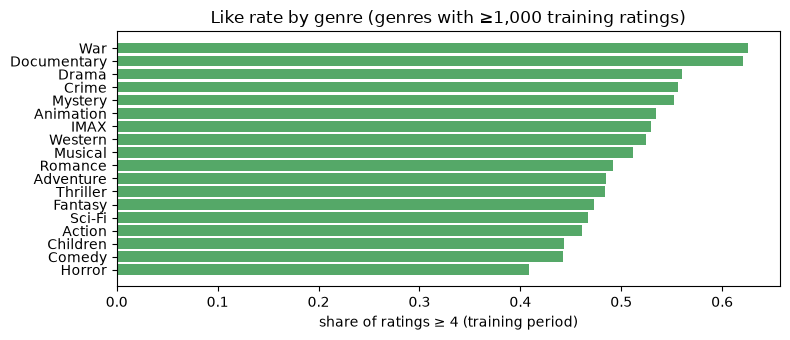

Highest like rate: War (62.6%); lowest: Horror (40.9%)


In [71]:
genre_like = sql(f"""
WITH train AS (SELECT * FROM ratings WHERE rated_at < TIMESTAMP '{CUTOFF}'),
genre_rows AS (
    SELECT t.rating, unnest(string_split(m.genres, '|')) AS genre
    FROM train AS t JOIN movies AS m USING (movie_id)
)
SELECT genre, COUNT(*) AS n_ratings,
       ROUND(AVG(CASE WHEN rating >= 4 THEN 1.0 ELSE 0.0 END), 3) AS like_rate
FROM genre_rows
GROUP BY genre
HAVING COUNT(*) >= 1000
ORDER BY like_rate DESC
""")

activity = sql(f"""
WITH per_user AS (
    SELECT user_id, COUNT(*) AS n FROM ratings WHERE rated_at < TIMESTAMP '{CUTOFF}' GROUP BY user_id
)
SELECT quantile_cont(n, 0.5) AS median_ratings_per_user, MAX(n) AS max_ratings_per_user,
       ROUND(100.0 * SUM(n) FILTER (WHERE n >= 500) / SUM(n), 1) AS pct_events_from_users_500_plus
FROM per_user
""")
print(activity.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(genre_like["genre"], genre_like["like_rate"], color="#55A868")
ax.invert_yaxis()
ax.set(xlabel="share of ratings ≥ 4 (training period)", title="Like rate by genre (genres with ≥1,000 training ratings)")
plt.tight_layout()
plt.show()
print(f"Highest like rate: {genre_like.iloc[0]['genre']} ({genre_like.iloc[0]['like_rate']:.1%}); "
      f"lowest: {genre_like.iloc[-1]['genre']} ({genre_like.iloc[-1]['like_rate']:.1%})")

### Step 3 — Point-in-time features in one SQL query

For every rating event we compute features from **strictly earlier** events only (named `WINDOW` clauses keep it readable). For comparison we also compute three **leaky** features using the whole partition.

In [72]:
features = sql("""
SELECT
    user_id, movie_id, rated_at, rating,
    CAST(rating >= 4 AS INTEGER)                                   AS liked,          -- the label
    -- ✅ point-in-time user features
    COUNT(*)                          OVER user_prior              AS user_prior_n,
    AVG(rating)                       OVER user_prior              AS user_prior_mean,
    AVG(CAST(rating >= 4 AS INTEGER)) OVER user_prior              AS user_prior_like_rate,
    date_diff('day', MAX(rated_at) OVER user_prior, rated_at)      AS days_since_prev,
    -- ✅ point-in-time movie features (from all users' earlier ratings)
    COUNT(*)                          OVER movie_prior             AS movie_prior_n,
    AVG(rating)                       OVER movie_prior             AS movie_prior_mean,
    -- ❌ leaky features: include this rating and future ratings
    AVG(rating) OVER (PARTITION BY user_id)                        AS leaky_user_mean,
    AVG(rating) OVER (PARTITION BY movie_id)                       AS leaky_movie_mean,
    COUNT(*)    OVER (PARTITION BY movie_id)                       AS leaky_movie_n
FROM ratings
WINDOW
    user_prior  AS (PARTITION BY user_id  ORDER BY rated_at RANGE BETWEEN UNBOUNDED PRECEDING AND INTERVAL 1 SECOND PRECEDING),
    movie_prior AS (PARTITION BY movie_id ORDER BY rated_at RANGE BETWEEN UNBOUNDED PRECEDING AND INTERVAL 1 SECOND PRECEDING)
ORDER BY rated_at, user_id, movie_id
""")
features.to_parquet(OUTPUT_DIR / "like_features.parquet", index=False)
print(f"{len(features):,} rows × {features.shape[1]} columns → saved to {OUTPUT_DIR / 'like_features.parquet'}")
features.head(3)

100,836 rows × 14 columns → saved to _outputs/like_features.parquet


,user_id,movie_id,rated_at,rating,liked,user_prior_n,user_prior_mean,user_prior_like_rate,days_since_prev,movie_prior_n,movie_prior_mean,leaky_user_mean,leaky_movie_mean,leaky_movie_n
0,429,22,1996-03-29 18:36:55,4.0,1,0,NaN,NaN,<NA>,0,NaN,3.982759,3.222222,36
1,429,150,1996-03-29 18:36:55,5.0,1,0,NaN,NaN,<NA>,0,NaN,3.982759,3.845771,201
2,429,161,1996-03-29 18:36:55,5.0,1,0,NaN,NaN,<NA>,0,NaN,3.982759,3.635922,103


### Step 4 — Sanity-check the features

Never trust a feature pipeline without tests. We recompute `user_prior_mean` for random events with a completely different method (a correlated subquery) and check that the first event of every user has no history.

In [73]:
sample = features.sample(200, random_state=0)[["user_id", "rated_at", "user_prior_n", "user_prior_mean"]]
recomputed = con.sql("""
    SELECT s.user_id, s.rated_at,
           (SELECT COUNT(*)      FROM ratings AS r WHERE r.user_id = s.user_id AND r.rated_at < s.rated_at) AS n,
           (SELECT AVG(r.rating) FROM ratings AS r WHERE r.user_id = s.user_id AND r.rated_at < s.rated_at) AS mean
    FROM sample AS s
""").df()
merged = sample.merge(recomputed, on=["user_id", "rated_at"])
assert (merged["user_prior_n"] == merged["n"]).all()
assert np.allclose(merged["user_prior_mean"].fillna(-1), merged["mean"].fillna(-1))

first_events = features.loc[features.groupby("user_id")["rated_at"].transform("min") == features["rated_at"]]
assert (first_events["user_prior_n"] == 0).all() and first_events["user_prior_mean"].isna().all()
print("✅ point-in-time features match an independent recomputation on 200 random events")
print(f"✅ all {first_events['user_id'].nunique()} users have zero history at their first event")

✅ point-in-time features match an independent recomputation on 200 random events
✅ all 610 users have zero history at their first event


### Step 5 — Train on the past, evaluate on the future

Missing history (a new user or movie) gives NULL means. We fill them with **training-period** averages — constants computed without touching the test period — and keep the `*_prior_n` counts so the model can tell "no history" apart. We don't tune any hyperparameters, so no validation split is needed here; the test set is used once.

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

is_train = features["rated_at"] < pd.Timestamp(CUTOFF)
train_df, test_df = features[is_train], features[~is_train]
fill_values = {
    "user_prior_mean": train_df["rating"].mean(),
    "movie_prior_mean": train_df["rating"].mean(),
    "user_prior_like_rate": train_df["liked"].mean(),
    "days_since_prev": -1,                                   # -1 = "no previous rating"
}
POINT_IN_TIME = ["user_prior_n", "user_prior_mean", "user_prior_like_rate", "days_since_prev", "movie_prior_n", "movie_prior_mean"]
LEAKY = ["leaky_user_mean", "leaky_movie_mean", "leaky_movie_n"]


def design(df, cols):
    return df[cols].fillna({c: v for c, v in fill_values.items() if c in cols}).astype(float)


results = {}
majority = int(train_df["liked"].mean() >= 0.5)
results["baseline: majority class"] = {"test AUC": 0.5, "test accuracy": accuracy_score(test_df["liked"], np.full(len(test_df), majority))}
for name, cols in [("point-in-time features", POINT_IN_TIME), ("leaky features", LEAKY)]:
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    model.fit(design(train_df, cols), train_df["liked"])
    proba = model.predict_proba(design(test_df, cols))[:, 1]
    results[name] = {"test AUC": roc_auc_score(test_df["liked"], proba),
                     "test accuracy": accuracy_score(test_df["liked"], proba >= 0.5)}

results_df = pd.DataFrame(results).T.round(3)
print(f"train: {len(train_df):,} events | test: {len(test_df):,} events (like rate {test_df['liked'].mean():.1%})\n")
print(results_df)

train: 86,220 events | test: 14,616 events (like rate 41.8%)

                          test AUC  test accuracy
baseline: majority class     0.500          0.582
point-in-time features       0.809          0.734
leaky features               0.855          0.772


### Step 6 — Results

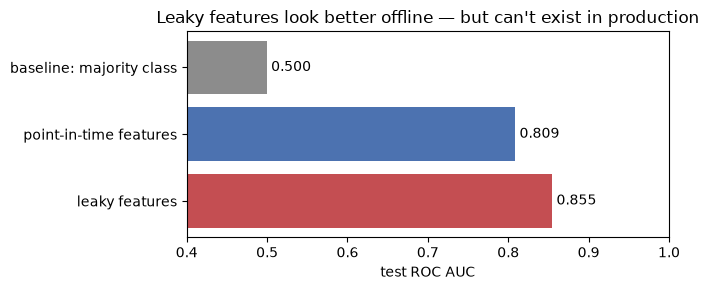

Point-in-time model: AUC 0.809, accuracy 73.4% vs 58.2% for always predicting the majority class.
The leaky pipeline reports AUC 0.855 (+0.046). That gain is fake: at prediction time nobody knows the user's future ratings or the rating being predicted.


In [75]:
fig, ax = plt.subplots(figsize=(7, 3))
colors = ["#8C8C8C", "#4C72B0", "#C44E52"]
ax.barh(results_df.index, results_df["test AUC"], color=colors)
for i, v in enumerate(results_df["test AUC"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set(xlim=(0.4, 1.0), xlabel="test ROC AUC", title="Leaky features look better offline — but can't exist in production")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

pit_auc = results["point-in-time features"]["test AUC"]
leak_auc = results["leaky features"]["test AUC"]
pit_acc = results["point-in-time features"]["test accuracy"]
base_acc = results["baseline: majority class"]["test accuracy"]
print(f"Point-in-time model: AUC {pit_auc:.3f}, accuracy {pit_acc:.1%} vs {base_acc:.1%} for always predicting the majority class.")
if leak_auc > pit_auc:
    print(f"The leaky pipeline reports AUC {leak_auc:.3f} (+{leak_auc - pit_auc:.3f}). That gain is fake: at prediction time "
          "nobody knows the user's future ratings or the rating being predicted.")
else:
    print("Here the leaky pipeline did not beat the point-in-time one — leakage does not always show up as a higher score, "
          "but it is still invalid.")

**Stretch goals**
1. Add a **genre affinity** feature: the user's prior like rate on movies sharing a genre with the current movie (window over an exploded genre table).
2. Add **recency-weighted** features: the user's average over the last 20 prior ratings (`ROWS BETWEEN 20 PRECEDING AND 1 PRECEDING` — and think about ties).
3. Carve a **validation period** (e.g. 2016) out of training, tune the regularization strength `C` there, and only then evaluate on 2017–2018.
4. Rewrite the feature query as an **incremental daily job**: compute features for one day's events from a stored per-user state table.

### 🗣️ How to talk about this in an interview
- "I framed it as predicting a like at rating time and used a **time-based split** (before/after 2017-01-01), because a random split leaks future behaviour into training."
- "All features are **point-in-time**: SQL window frames that end one second before the event, so even ratings in the same second can't see each other. I validated them against an independent correlated-subquery recomputation."
- "A leaky version using all-time averages scored higher offline — a concrete demonstration of why offline/online skew happens."
- "Cold-start users and movies get NULL history, which I filled with training-period constants while keeping the count features so the model knows history is missing."
- "In production I'd compute these in a scheduled SQL job partitioned by date, and serve the same definitions online through a feature store to avoid training–serving skew."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the logical order in which a SELECT query is evaluated, and why does it matter?**

<details><summary>Show answer</summary>

- **30-second answer:** `FROM/JOIN → WHERE → GROUP BY → HAVING → SELECT → window functions → QUALIFY → DISTINCT → ORDER BY → LIMIT`. It explains why `WHERE` can't use aggregates or (in standard SQL) `SELECT` aliases, why window functions can't be filtered in `WHERE`, and why `ORDER BY` can use aliases.
- **Go deeper:** It's a *logical* order — the optimizer may physically push filters into scans or reorder joins, but the result must be as if this order were followed.
- **❌ Common wrong answer:** "SQL runs top to bottom as written, starting with SELECT."

</details>

**Q2. What's the difference between WHERE and HAVING?**

<details><summary>Show answer</summary>

- **30-second answer:** `WHERE` filters rows before grouping and can't use aggregates; `HAVING` filters groups after aggregation, e.g. `HAVING COUNT(*) >= 50`.
- **Go deeper:** Put non-aggregate conditions in `WHERE` — fewer rows reach the aggregation, so it's cheaper. Most optimizers will move a non-aggregate `HAVING` condition down anyway.
- **❌ Common wrong answer:** "They're the same; HAVING is just for GROUP BY queries."

</details>

**Q3. Explain ROW_NUMBER, RANK and DENSE_RANK. When would you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** For scores 90, 85, 85, 80: `ROW_NUMBER` → 1,2,3,4 (unique, arbitrary among ties), `RANK` → 1,2,2,4 (gaps), `DENSE_RANK` → 1,2,2,3 (no gaps). Use `ROW_NUMBER` for dedupe or exactly N rows, `RANK`/`DENSE_RANK` when ties must be kept; `DENSE_RANK` for "N-th highest distinct value".
- **Go deeper:** Always add a deterministic tiebreaker to `ROW_NUMBER`'s `ORDER BY`, or reruns can return different rows.
- **❌ Common wrong answer:** "RANK and DENSE_RANK are identical."

</details>

**Q4. How do NULLs behave in comparisons, aggregates and NOT IN?**

<details><summary>Show answer</summary>

- **30-second answer:** Comparisons with NULL are UNKNOWN (three-valued logic), and `WHERE` keeps only TRUE. `COUNT(*)` counts rows while `COUNT(col)`, `SUM`, `AVG` skip NULLs. `x NOT IN (subquery containing NULL)` is never TRUE, so it returns no rows.
- **Go deeper:** Use `IS NULL`, `IS [NOT] DISTINCT FROM` for NULL-safe equality, `COALESCE` for defaults, and `NOT EXISTS` for anti joins. `GROUP BY` treats all NULLs as one group.
- **❌ Common wrong answer:** "NULL = NULL is TRUE" or "AVG treats NULL as 0."

</details>

**Q5. What is a semi join and an anti join? How do you write them portably?**

<details><summary>Show answer</summary>

- **30-second answer:** Semi join: left rows with at least one match, never duplicated — `WHERE EXISTS (...)` or `IN`. Anti join: left rows with no match — `WHERE NOT EXISTS (...)` or `LEFT JOIN ... WHERE right.key IS NULL`.
- **Go deeper:** An `INNER JOIN` used as a "filter" duplicates left rows when the right key repeats. Prefer `NOT EXISTS` to `NOT IN` because of NULLs. Some engines (DuckDB, Spark) have `SEMI`/`ANTI JOIN` keywords.
- **❌ Common wrong answer:** "Just INNER JOIN and add DISTINCT" — works sometimes, but hides the fan-out and costs extra work.

</details>

**Q6. CTE vs subquery vs temp table — which do you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** CTEs and subqueries are logically the same; CTEs are more readable and reusable within one query. A temp table materializes results you reuse across several queries or want to inspect.
- **Go deeper:** Postgres 12+ inlines non-recursive, side-effect-free CTEs referenced once (older versions always materialized them, acting as an optimization fence); `WITH x AS MATERIALIZED` forces materialization. Recursive CTEs handle hierarchies and graphs.
- **❌ Common wrong answer:** "CTEs are always faster" or "always slower".

</details>

**Q7. Why are analytical databases like DuckDB, BigQuery or Snowflake fast on aggregations over billions of rows?**

<details><summary>Show answer</summary>

- **30-second answer:** Columnar storage (read only needed columns, great compression), vectorized execution (process batches of values in tight loops), parallelism, and data skipping via zone maps and partition pruning.
- **Go deeper:** Row stores (Postgres, MySQL) optimize for OLTP — reading/writing whole rows by key with B-tree indexes. OLAP engines trade fast single-row updates for fast scans. DuckDB additionally runs in-process, so there's no network transfer between the database and Python.
- **❌ Common wrong answer:** "Because they have more indexes."

</details>

### 💻 Coding

**Q8. Return the second-highest salary from `employees`, or NULL if there isn't one.**

<details><summary>Show answer</summary>

- **30-second answer:** `SELECT (SELECT DISTINCT salary FROM employees ORDER BY salary DESC LIMIT 1 OFFSET 1) AS second_highest;` — or `SELECT MAX(salary) FROM employees WHERE salary < (SELECT MAX(salary) FROM employees)`.
- **Go deeper:** Generalize to N-th with `DENSE_RANK() OVER (ORDER BY salary DESC) = N`. The outer scalar subquery turns "no rows" into NULL. Clarify whether ties count as one value (they usually do → `DISTINCT`/`DENSE_RANK`).
- **❌ Common wrong answer:** `ORDER BY salary DESC LIMIT 1 OFFSET 1` without `DISTINCT` — returns the top salary again when it's tied.

</details>

**Q9. Get the top 3 products by revenue in each category.**

<details><summary>Show answer</summary>

- **30-second answer:** Aggregate revenue per (category, product) in a CTE, add `ROW_NUMBER() OVER (PARTITION BY category ORDER BY revenue DESC, product)`, and filter `rn <= 3` in an outer query (or `QUALIFY`).
- **Go deeper:** Ask about ties → `RANK`/`DENSE_RANK`. Window functions can't go in `WHERE` because they're computed after it.
- **❌ Common wrong answer:** `GROUP BY category ORDER BY revenue DESC LIMIT 3` — that returns 3 rows total, not per category.

</details>

**Q10. Compute a 7-day rolling average of daily active users when some days have no data.**

<details><summary>Show answer</summary>

- **30-second answer:** Build a calendar with `generate_series`, `LEFT JOIN` daily counts with `COALESCE(n, 0)`, then `AVG(n) OVER (ORDER BY day ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)`.
- **Go deeper:** Without the calendar, `ROWS 6 PRECEDING` may span more than 7 days. Alternatively `RANGE BETWEEN INTERVAL 6 DAYS PRECEDING AND CURRENT ROW` works on the raw rows, but missing days are then ignored instead of counted as 0 — decide which the business wants. Note "distinct users over 7 days" is *not* the average of daily counts.
- **❌ Common wrong answer:** Using the default frame, or averaging over whatever 7 rows exist.

</details>

**Q11. A table has duplicate events per `event_id` from retries. Keep only the latest version of each.**

<details><summary>Show answer</summary>

- **30-second answer:** `SELECT * FROM events QUALIFY ROW_NUMBER() OVER (PARTITION BY event_id ORDER BY updated_at DESC, ingestion_id DESC) = 1` (or the same inside a CTE with `WHERE rn = 1`).
- **Go deeper:** Add a deterministic tiebreaker for identical timestamps. For pipelines, make the dedupe idempotent (e.g. `MERGE`/upsert on `event_id`).
- **❌ Common wrong answer:** `SELECT DISTINCT *` — rows differing in any column (like `updated_at`) are not duplicates to `DISTINCT`.

</details>

### 🐛 Debugging Scenarios

**Q12. After joining `orders` to `payments`, total revenue is 2–3× higher than finance reports. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Fan-out: `payments` has several rows per order (split payments, retries), so each order row is repeated and `SUM(order_amount)` is multiplied. Aggregate payments to one row per order first, then join.
- **Go deeper:** Check grain with `COUNT(*)` vs `COUNT(DISTINCT order_id)` on each side; add a uniqueness test in the pipeline (dbt `unique` tests do exactly this).
- **❌ Common wrong answer:** "Add DISTINCT to the SUM" — `SUM(DISTINCT amount)` drops legitimately equal amounts from different orders.

</details>

**Q13. A LEFT JOIN query returns exactly as many rows as an INNER JOIN would. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** A `WHERE` condition on a right-table column (e.g. `WHERE p.status = 'paid'`) rejects the NULL-padded rows, turning it into an inner join. Move the condition into the `ON` clause, or use `WHERE p.status = 'paid' OR p.order_id IS NULL` if that's the intent.
- **Go deeper:** Filters on the *left* table belong in `WHERE`; filters on the *right* table that define "what counts as a match" belong in `ON`.
- **❌ Common wrong answer:** "The database converted it for performance" — the optimizer only does that because the query's meaning already made it an inner join.

</details>

**Q14. Your churn model had 0.92 AUC offline but performs near random in production. The features come from SQL. What do you look for?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage: features computed with data not available at prediction time — all-time aggregates, joins to the *current* snapshot of a table (e.g. `account_status = 'closed'`), or windows including the label event. Rebuild with point-in-time windows / as-of joins and a time-based split.
- **Go deeper:** Also check training–serving skew (different code paths online vs offline), timezone/bucketing mismatches, and a random split on time-ordered data. Feature stores provide point-in-time-correct training sets for this reason.
- **❌ Common wrong answer:** "The model is overfitting — add regularization."

</details>

### 🏗️ Design

**Q15. Design a daily SQL pipeline that produces user features for a recommender model.**

<details><summary>Show answer</summary>

- **30-second answer:** Raw events land partitioned by date → a daily job computes features *as of the end of each day* from events up to that day → writes one partition per day to a feature table (overwrite-partition, so reruns are idempotent) → training joins labels to the feature partition from *before* the label time; serving reads the latest partition or an online store.
- **Go deeper:** Use incremental state (yesterday's per-user aggregates + today's events) instead of rescanning history; backfill by rerunning date partitions; add data-quality checks (row counts, NULL rates, key uniqueness, freshness) that block bad partitions; version feature definitions; keep offline and online computation from one definition to avoid skew.
- **❌ Common wrong answer:** "Recompute all features over all history every day and overwrite the table" — expensive, not reproducible for past training sets, and destroys point-in-time history.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `SELECT COUNT(*), COUNT(x) FROM (VALUES (1), (NULL), (3)) AS t(x)`
<details><summary>Answer</summary>

`3, 2` — `COUNT(*)` counts rows; `COUNT(x)` skips the NULL.
</details>

**2.** `SELECT NULL = NULL`
<details><summary>Answer</summary>

`NULL` — comparing two unknowns is unknown. Use `IS NULL` or `IS NOT DISTINCT FROM`.
</details>

**3.** Left table keys `[1, 1, 2]`, right table keys `[1, 1, 1, 3]`. How many rows does an `INNER JOIN` on the key return?
<details><summary>Answer</summary>

`6` — key 1 appears 2 × 3 times; keys 2 and 3 have no match.
</details>

**4.** `RANK() OVER (ORDER BY score DESC)` for scores `90, 85, 85, 80`?
<details><summary>Answer</summary>

`1, 2, 2, 4` — `RANK` leaves a gap after ties (`DENSE_RANK` would give `1, 2, 2, 3`).
</details>

**5.** How many rows does `SELECT 1 WHERE 3 NOT IN (1, NULL)` return?
<details><summary>Answer</summary>

**0** — `3 <> NULL` is UNKNOWN, so the whole `NOT IN` is UNKNOWN, and `WHERE` keeps only TRUE.
</details>

## 📚 Resources

### 📖 Official Docs
- [SQL Introduction – DuckDB](https://duckdb.org/docs/current/sql/introduction.html) — create tables, query, join, aggregate
- [Window Functions – DuckDB](https://duckdb.org/docs/current/sql/functions/window_functions.html) — every window function and frame option
- [QUALIFY Clause – DuckDB](https://duckdb.org/docs/current/sql/query_syntax/qualify.html) — filtering on window functions
- [NULL Values – DuckDB](https://duckdb.org/docs/current/sql/data_types/nulls.html) — three-valued logic in detail
- [SQL on Pandas – DuckDB](https://duckdb.org/docs/current/guides/python/sql_on_pandas.html) · [Reading and Writing Parquet Files – DuckDB](https://duckdb.org/docs/current/data/parquet/overview.html) · [Hive Partitioning – DuckDB](https://duckdb.org/docs/current/data/partitioning/hive_partitioning.html)
- [EXPLAIN: Inspect Query Plans – DuckDB](https://duckdb.org/docs/current/guides/meta/explain.html) — reading query plans
- [pandas: Comparison with SQL](https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_sql.html) — official SQL ↔ pandas translation guide
- [PostgreSQL: Window Functions tutorial](https://www.postgresql.org/docs/current/tutorial-window.html) — the classic, dialect-neutral explanation
- Dataset: [MovieLens Latest Datasets | GroupLens](https://grouplens.org/datasets/movielens/latest/) · [Hugging Face mirror used as fallback](https://huggingface.co/datasets/johnidouglas/movie_lens_small_latest)

### 🎥 Videos
- [freeCodeCamp.org — SQL Tutorial - Full Database Course for Beginners](https://www.youtube.com/watch?v=HXV3zeQKqGY) (4 h 20 m) — if you're brand-new to databases, this covers tables, keys and basic queries slowly and thoroughly
- [techTFQ — SQL Window Function | How to write SQL Query using RANK, DENSE RANK, LEAD/LAG](https://www.youtube.com/watch?v=Ww71knvhQ-s) (25 m) — a clear, interview-focused walkthrough of the window functions in sections 9–10
- [CMU Database Group — DuckDB – The SQLite for Analytics (Mark Raasveldt, CWI)](https://www.youtube.com/watch?v=PFUZlNQIndo) (1 h 08 m) — a DuckDB co-creator explains columnar, vectorized, in-process design; great for the "why is it fast?" question

### 📄 Papers
- [Codd (1970) — A Relational Model of Data for Large Shared Data Banks](https://dl.acm.org/doi/10.1145/362384.362685) — the paper that started relational databases
- [Raasveldt & Mühleisen (2019) — DuckDB: an Embeddable Analytical Database (SIGMOD demo)](https://duckdb.org/pdf/SIGMOD2019-demo-duckdb.pdf) — the short design paper behind DuckDB
- [Leis et al. (2015) — How Good Are Query Optimizers, Really?](https://www.vldb.org/pvldb/vol9/p204-leis.pdf) — why cardinality estimates (the "~rows" in EXPLAIN) matter so much
- [Harper & Konstan (2015) — The MovieLens Datasets: History and Context](https://doi.org/10.1145/2827872) — how the dataset used here was collected

### 📘 Books & Courses
- [Mode SQL Tutorial](https://mode.com/sql-tutorial/) — free, from basic to advanced analytics SQL
- [Select Star SQL](https://selectstarsql.com/) — a free interactive book built around one real dataset
- [Use The Index, Luke](https://use-the-index-luke.com/) — free book on indexes and SQL performance for developers
- [Kaggle Learn — Intro to SQL](https://www.kaggle.com/learn/intro-to-sql) — short hands-on course

### 🏋️ Practice
- [LeetCode — Top SQL 50](https://leetcode.com/studyplan/top-sql-50/) — the standard interview study plan
- [DataLemur SQL Interview Questions](https://datalemur.com/sql-interview-questions) — real questions from tech companies, with explanations
- [StrataScratch](https://www.stratascratch.com/) — data science and SQL interview questions
- [PostgreSQL Exercises](https://pgexercises.com/) — graded exercises from joins to window functions and recursive queries
- [SQLBolt](https://sqlbolt.com/) — bite-sized interactive lessons for absolute beginners

## 📝 Summary Cheat Sheet

| Concept | What it does | Key syntax / rule |
|---|---|---|
| Execution order | how clauses are evaluated | FROM → WHERE → GROUP BY → HAVING → SELECT → window → QUALIFY → DISTINCT → ORDER BY → LIMIT |
| Filter & sort | pick and order rows | `WHERE`, `IN`, `BETWEEN`, `LIKE/ILIKE`, `ORDER BY … NULLS LAST`, `LIMIT` |
| Expressions | compute columns | `CASE WHEN … THEN … ELSE … END`, `CAST`, `regexp_extract`, `COALESCE` |
| Aggregates | many rows → one per group | `COUNT(*)` vs `COUNT(col)`, `SUM`, `AVG`, `FILTER (WHERE …)`, `HAVING` |
| Joins | combine tables | inner / left / full / cross; output = a × b rows per key; check grain first |
| Semi / anti join | exists / not exists | `EXISTS`, `NOT EXISTS` (NULL-safe), `LEFT JOIN … IS NULL` |
| NULLs | unknown values | three-valued logic, `IS [NOT] DISTINCT FROM`, avoid `NOT IN` with NULLs |
| CTEs | named steps | `WITH a AS (…), b AS (…) SELECT …` |
| Ranking windows | order within groups | `ROW_NUMBER`/`RANK`/`DENSE_RANK() OVER (PARTITION BY … ORDER BY …)` + `QUALIFY` |
| Value windows | look around rows | `LAG`/`LEAD`, `SUM(x) OVER (ORDER BY t ROWS BETWEEN … )`, `SUM(x) OVER ()` for % of total |
| Dates | bucket and compare time | `date_trunc`, `time_bucket`, `date_diff` (counts boundaries), `generate_series` |
| DuckDB I/O | query data in place | `FROM df_variable`, `FROM 'file.parquet'`, `COPY … TO … (FORMAT parquet, PARTITION_BY …)`, `.df()` |
| Performance | understand plans | `EXPLAIN [ANALYZE]`, pushdown, partition pruning, indexes for OLTP point lookups |
| Point-in-time features | no leakage | frames ending before the event, `ASOF JOIN`, time-based split |

## ➡️ What's Next

**[04 · Math for ML](04_Math_for_ML.ipynb)** — you can now pull clean, leakage-free features out of real data; next you'll learn the vectors, matrices, gradients and information theory that models use to learn from those features.